## 1. Importação de Bibliotecas


In [7]:
# Manipulação de dados
import pandas as pd
import numpy as np
from datetime import datetime

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning - Pré-processamento
import sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold

# Machine Learning - Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Machine Learning - Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    mean_absolute_error,
    roc_auc_score,
    precision_recall_fscore_support
)

# Persistência
import joblib
import pickle

# Configurações
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Configurar pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"Pandas versão: {pd.__version__}")
print(f"NumPy versão: {np.__version__}")

Pandas versão: 3.0.1
NumPy versão: 2.4.2


## 2. Carregamento dos Dados

O arquivo Excel possui **3 abas**, uma para cada ano de pesquisa:
- **PEDE2022**: Dados de 2022 (860 alunos)
- **PEDE2023**: Dados de 2023 (1.014 alunos)
- **PEDE2024**: Dados de 2024 (1.156 alunos)

In [ ]:
# Caminho do arquivo Excel
excel_file = 'BASE_DE_DADOS_PEDE_2024_-_DATATHON.xlsx'

print("="*80)
print("📊 CARREGANDO DADOS DO EXCEL")
print("="*80)

# Carregar cada aba e removendo alunos que tem mais de 19 anos
df_2022 = pd.read_excel(excel_file, sheet_name='PEDE2022')
df_2022 = df_2022[df_2022['Idade 22'] <= 19]

df_2023 = pd.read_excel(excel_file, sheet_name='PEDE2023')
df_2023['Idade'] = pd.to_numeric(df_2023['Idade'], errors='coerce')
df_2023 = df_2023[df_2023['Idade'] <= 19]

df_2024 = pd.read_excel(excel_file, sheet_name='PEDE2024')
df_2024 = df_2024[df_2024['Idade'] <= 19]

print(f"\nDados carregados com sucesso!")
print(f"\nDimensões dos datasets:")
print(f"   • PEDE 2022: {df_2022.shape[0]} alunos x {df_2022.shape[1]} colunas")
print(f"   • PEDE 2023: {df_2023.shape[0]} alunos x {df_2023.shape[1]} colunas")
print(f"   • PEDE 2024: {df_2024.shape[0]} alunos x {df_2024.shape[1]} colunas")
print(f"\nTotal de alunos ao longo dos anos: {df_2022.shape[0] + df_2023.shape[0] + df_2024.shape[0]}")

📊 CARREGANDO DADOS DO EXCEL

✅ Dados carregados com sucesso!

📏 Dimensões dos datasets:
   • PEDE 2022: 857 alunos x 42 colunas
   • PEDE 2023: 598 alunos x 48 colunas
   • PEDE 2024: 1081 alunos x 50 colunas

👥 Total de alunos ao longo dos anos: 2536


### 2.1. Visualização Inicial - PEDE 2022

In [ ]:
print("="*80)
print("📄 PEDE 2022 - PRIMEIRAS LINHAS")
print("="*80)
df_2022.head()

📄 PEDE 2022 - PRIMEIRAS LINHAS


,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Matem,Portug,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,5.78,753,18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,8.30,4.10,5.60,Requer avaliação,4.00,2.70,3.50,6.00,Sim,Não,7.28,5.00,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,7.05,469,8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,8.80,5.20,6.30,Sem limitações,6.80,6.30,4.50,9.70,Não,Não,6.78,10.00,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ágata,6.59,629,13,6,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,0.00,7.90,5.60,Sem limitações,5.60,5.80,4.00,6.90,Não,Não,7.56,10.00,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.95,731,15,7,4,Avaliador-5,Promovido de Fase,Avaliador-27,Mantido na Fase atual,Avaliador-28,Mantido na Fase atual,Avaliador-31,Mantido na Fase atual,8.80,4.50,5.60,Requer avaliação,5.00,2.80,3.50,8.70,Não,Não,5.28,10.00,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,Ametista,Ametista,7.43,344,6,2,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase + Bolsa,Avaliador-31,Promovido de Fase + Bolsa,7.90,8.60,5.60,Requer avaliação,5.20,7.00,2.90,5.70,Não,Não,7.39,10.00,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


In [ ]:
print("📊 PEDE 2022 - INFORMAÇÕES DAS COLUNAS")
df_2022.info()

📊 PEDE 2022 - INFORMAÇÕES DAS COLUNAS
<class 'pandas.core.frame.DataFrame'>
Index: 857 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     857 non-null    object 
 1   Fase                   857 non-null    int64  
 2   Turma                  857 non-null    object 
 3   Nome                   857 non-null    object 
 4   Ano nasc               857 non-null    int64  
 5   Idade 22               857 non-null    int64  
 6   Gênero                 857 non-null    object 
 7   Ano ingresso           857 non-null    int64  
 8   Instituição de ensino  857 non-null    object 
 9   Pedra 20               322 non-null    object 
 10  Pedra 21               461 non-null    object 
 11  Pedra 22               857 non-null    object 
 12  INDE 22                857 non-null    float64
 13  Cg                     857 non-null    int64  
 14  Cf                     85

### 2.2. Visualização Inicial - PEDE 2023

In [ ]:
print("="*80)
print("📄 PEDE 2023 - PRIMEIRAS LINHAS")
print("="*80)
df_2023.head()

📄 PEDE 2023 - PRIMEIRAS LINHAS


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,9.31,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8.00,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,9.50,10.00,8.13,8.44,NaN,9.60,9.80,9.40,NaN,NaN,NaN,8.92,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,8.22,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9.00,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,8.50,9.10,8.14,7.50,NaN,8.90,8.50,9.20,NaN,NaN,NaN,8.59,5.00,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN
2,RA-863,ALFA,5.93,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7.00,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,0.00,7.60,3.14,5.94,NaN,6.30,7.00,5.50,NaN,NaN,NaN,6.26,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
4,RA-865,ALFA,8.16,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8.00,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,8.50,8.70,7.52,7.50,NaN,7.40,7.30,7.50,NaN,NaN,NaN,7.92,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
6,RA-867,ALFA,8.70,Topázio,ALFA A - G0/G1,Aluno-867,6/29/2015,8.00,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,9.00,8.60,8.76,7.50,NaN,8.90,8.70,9.00,NaN,NaN,NaN,8.41,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN


In [ ]:
print("PEDE 2023 - INFORMAÇÕES DAS COLUNAS")
df_2023.info()

📊 PEDE 2023 - INFORMAÇÕES DAS COLUNAS
<class 'pandas.core.frame.DataFrame'>
Index: 598 entries, 0 to 1012
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     598 non-null    object 
 1   Fase                   598 non-null    object 
 2   INDE 2023              563 non-null    float64
 3   Pedra 2023             563 non-null    object 
 4   Turma                  598 non-null    object 
 5   Nome Anonimizado       598 non-null    object 
 6   Data de Nasc           598 non-null    object 
 7   Idade                  598 non-null    float64
 8   Gênero                 598 non-null    object 
 9   Ano ingresso           598 non-null    int64  
 10  Instituição de ensino  598 non-null    object 
 11  Pedra 20               139 non-null    object 
 12  Pedra 21               199 non-null    object 
 13  Pedra 22               353 non-null    object 
 14  Pedra 23               0

### 2.3. Visualização Inicial - PEDE 2024

In [ ]:
print("="*80)
print("📄 PEDE 2024 - PRIMEIRAS LINHAS")
print("="*80)
df_2024.head()

📄 PEDE 2024 - PRIMEIRAS LINHAS


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Avaliador4,Avaliador5,Avaliador6,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.61,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.00,8.67,6.26,5.62,NaN,8.00,10.00,6.00,NaN,NaN,NaN,5.45,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.00,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.00,9.33,3.76,7.50,NaN,8.00,10.00,6.00,NaN,NaN,NaN,7.05,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.95,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,10.00,9.08,3.76,7.50,NaN,8.00,10.00,6.00,NaN,NaN,NaN,7.05,10.00,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.16,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,Pública,NaN,NaN,NaN,Topázio,NaN,8.64,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,8.00,9.75,3.76,6.88,NaN,7.00,8.00,6.00,NaN,NaN,NaN,7.21,5.00,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.44,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,9.00,4.17,3.76,5.00,NaN,7.50,8.00,7.00,NaN,NaN,NaN,4.17,5.00,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


In [ ]:
print("PEDE 2024 - INFORMAÇÕES DAS COLUNAS")
df_2024.info()

📊 PEDE 2024 - INFORMAÇÕES DAS COLUNAS
<class 'pandas.core.frame.DataFrame'>
Index: 1081 entries, 0 to 1117
Data columns (total 50 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   RA                     1081 non-null   object        
 1   Fase                   1081 non-null   object        
 2   INDE 2024              1054 non-null   object        
 3   Pedra 2024             1054 non-null   object        
 4   Turma                  1081 non-null   object        
 5   Nome Anonimizado       1081 non-null   object        
 6   Data de Nasc           1081 non-null   datetime64[ns]
 7   Idade                  1081 non-null   int64         
 8   Gênero                 1081 non-null   object        
 9   Ano ingresso           1081 non-null   int64         
 10  Instituição de ensino  1080 non-null   object        
 11  Pedra 20               189 non-null    object        
 12  Pedra 21               261 no

## 3. Análise Exploratória de Dados (EDA)

Vamos explorar cada dataset individualmente e depois fazer uma análise temporal comparativa.

### 3.1. Análise da Variável Target: Defasagem

A variável **Defasagem** (ou **Defas** em 2022) é nossa variável alvo:
- **Valores negativos**: aluno está atrasado (ex: -1 = 1 ano de atraso)
- **Zero (0)**: aluno está no nível ideal
- **Valores positivos**: aluno está adiantado

In [ ]:
print("="*80)
print("🎯 ANÁLISE DA DEFASAGEM POR ANO")
print("="*80)

# Padronizar nome da coluna
if 'Defas' in df_2022.columns:
    df_2022['Defasagem'] = df_2022['Defas']

# Análise para cada ano
anos = [2022, 2023, 2024]
dataframes = [df_2022, df_2023, df_2024]

for ano, df in zip(anos, dataframes):
    print(f"\n{'─'*80}")
    print(f"📅 ANO {ano}")
    print(f"{'─'*80}")

    defasagem_counts = df['Defasagem'].value_counts().sort_index()
    defasagem_pct = df['Defasagem'].value_counts(normalize=True).sort_index() * 100

    print("\n📊 Distribuição:")
    for def_val, count, pct in zip(defasagem_counts.index, defasagem_counts.values, defasagem_pct.values):
        print(f"   Defasagem {def_val:+2d}: {count:4d} alunos ({pct:5.1f}%)")

    print(f"\n📐 Estatísticas:")
    print(f"   Média: {df['Defasagem'].mean():.2f} anos")
    print(f"   Mediana: {df['Defasagem'].median():.2f} anos")
    print(f"   Desvio padrão: {df['Defasagem'].std():.2f} anos")

    print(f"\n💡 Resumo:")
    pct_ideal = (df['Defasagem'] == 0).sum() / len(df) * 100
    pct_atrasados = (df['Defasagem'] < 0).sum() / len(df) * 100
    pct_adiantados = (df['Defasagem'] > 0).sum() / len(df) * 100
    print(f"No nível ideal: {pct_ideal:.1f}%")
    print(f"Atrasados: {pct_atrasados:.1f}%")
    print(f"Adiantados: {pct_adiantados:.1f}%")

🎯 ANÁLISE DA DEFASAGEM POR ANO

────────────────────────────────────────────────────────────────────────────────
📅 ANO 2022
────────────────────────────────────────────────────────────────────────────────

📊 Distribuição:
   Defasagem -5:    1 alunos (  0.1%)
   Defasagem -4:    4 alunos (  0.5%)
   Defasagem -3:   23 alunos (  2.7%)
   Defasagem -2:  163 alunos ( 19.0%)
   Defasagem -1:  407 alunos ( 47.5%)
   Defasagem +0:  247 alunos ( 28.8%)
   Defasagem +1:    9 alunos (  1.1%)
   Defasagem +2:    3 alunos (  0.4%)

📐 Estatísticas:
   Média: -0.94 anos
   Mediana: -1.00 anos
   Desvio padrão: 0.85 anos

💡 Resumo:
   ✅ No nível ideal: 28.8%
   ⚠️ Atrasados: 69.8%
   ⭐ Adiantados: 1.4%

────────────────────────────────────────────────────────────────────────────────
📅 ANO 2023
────────────────────────────────────────────────────────────────────────────────

📊 Distribuição:
   Defasagem -4:    1 alunos (  0.2%)
   Defasagem -3:    7 alunos (  1.2%)
   Defasagem -2:   77 alunos ( 12.9

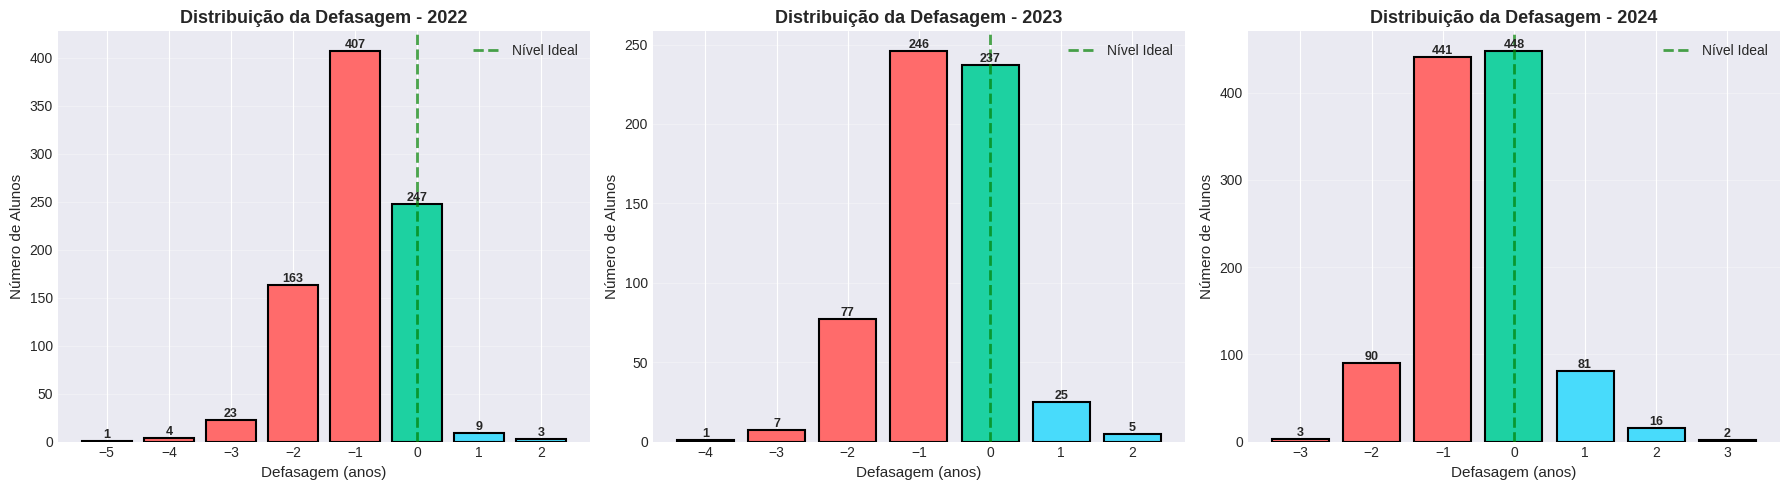

In [ ]:
# Visualização comparativa da defasagem
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (ano, df) in enumerate(zip(anos, dataframes)):
    defasagem_counts = df['Defasagem'].value_counts().sort_index()

    colors = ['#ff6b6b' if x < 0 else '#1dd1a1' if x == 0 else '#48dbfb' for x in defasagem_counts.index]
    bars = axes[idx].bar(defasagem_counts.index, defasagem_counts.values, color=colors, edgecolor='black', linewidth=1.5)

    axes[idx].set_title(f'Distribuição da Defasagem - {ano}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Defasagem (anos)', fontsize=11)
    axes[idx].set_ylabel('Número de Alunos', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].axvline(x=0, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Nível Ideal')

    # Adicionar valores nas barras
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height)}',
                      ha='center', va='bottom', fontweight='bold', fontsize=9)

    axes[idx].legend()

plt.tight_layout()
plt.show()


### 3.2. Evolução Temporal: Comparação 2022-2024


In [ ]:
print("="*80)
print("📈 EVOLUÇÃO TEMPORAL DOS INDICADORES")
print("="*80)

# Preparar dados para comparação temporal
evolucao_defasagem = pd.DataFrame({
    'Ano': [2022, 2023, 2024],
    'N_Alunos': [len(df_2022), len(df_2023), len(df_2024)],
    'Defasagem_Media': [
        df_2022['Defasagem'].mean(),
        df_2023['Defasagem'].mean(),
        df_2024['Defasagem'].mean()
    ],
    'Pct_Nivel_Ideal': [
        (df_2022['Defasagem'] == 0).sum() / len(df_2022) * 100,
        (df_2023['Defasagem'] == 0).sum() / len(df_2023) * 100,
        (df_2024['Defasagem'] == 0).sum() / len(df_2024) * 100
    ],
    'Pct_Atrasados': [
        (df_2022['Defasagem'] < 0).sum() / len(df_2022) * 100,
        (df_2023['Defasagem'] < 0).sum() / len(df_2023) * 100,
        (df_2024['Defasagem'] < 0).sum() / len(df_2024) * 100
    ]
})

print("\n📊 Resumo da Evolução:")
print(evolucao_defasagem.to_string(index=False))

# Calcular variação
var_ideal = evolucao_defasagem.loc[2, 'Pct_Nivel_Ideal'] - evolucao_defasagem.loc[0, 'Pct_Nivel_Ideal']
var_atrasados = evolucao_defasagem.loc[2, 'Pct_Atrasados'] - evolucao_defasagem.loc[0, 'Pct_Atrasados']

print(f"\n💡 VARIAÇÃO 2022 → 2024:")
print(f"   • Alunos no nível ideal: {var_ideal:+.1f} pontos percentuais")
print(f"   • Alunos atrasados: {var_atrasados:+.1f} pontos percentuais")

📈 EVOLUÇÃO TEMPORAL DOS INDICADORES

📊 Resumo da Evolução:
 Ano  N_Alunos  Defasagem_Media  Pct_Nivel_Ideal  Pct_Atrasados
2022       857            -0.94            28.82          69.78
2023       598            -0.65            39.63          55.35
2024      1081            -0.47            41.44          49.40

💡 VARIAÇÃO 2022 → 2024:
   • Alunos no nível ideal: +12.6 pontos percentuais
   • Alunos atrasados: -20.4 pontos percentuais


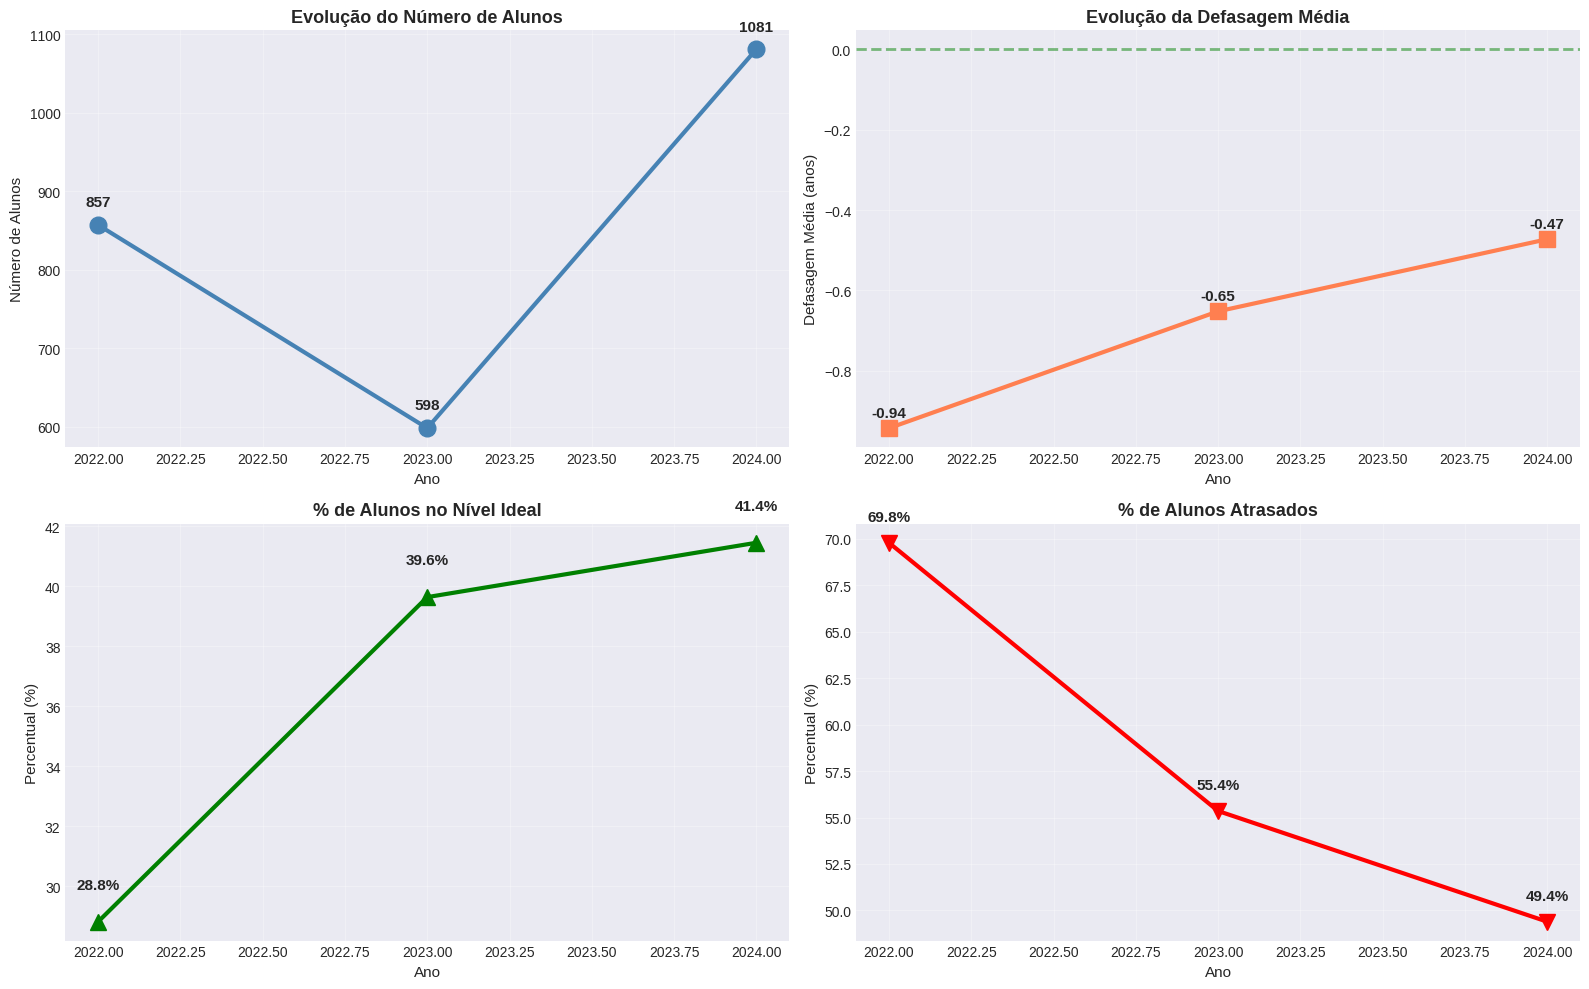

In [ ]:
# Visualização da evolução
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Número de alunos
axes[0, 0].plot(evolucao_defasagem['Ano'], evolucao_defasagem['N_Alunos'],
                marker='o', linewidth=3, markersize=12, color='steelblue')
axes[0, 0].set_title('Evolução do Número de Alunos', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Ano', fontsize=11)
axes[0, 0].set_ylabel('Número de Alunos', fontsize=11)
axes[0, 0].grid(alpha=0.3)
for x, y in zip(evolucao_defasagem['Ano'], evolucao_defasagem['N_Alunos']):
    axes[0, 0].text(x, y+20, str(y), ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Defasagem média
axes[0, 1].plot(evolucao_defasagem['Ano'], evolucao_defasagem['Defasagem_Media'],
                marker='s', linewidth=3, markersize=12, color='coral')
axes[0, 1].set_title('Evolução da Defasagem Média', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Ano', fontsize=11)
axes[0, 1].set_ylabel('Defasagem Média (anos)', fontsize=11)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5)
for x, y in zip(evolucao_defasagem['Ano'], evolucao_defasagem['Defasagem_Media']):
    axes[0, 1].text(x, y+0.02, f'{y:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 3. % Alunos no nível ideal
axes[1, 0].plot(evolucao_defasagem['Ano'], evolucao_defasagem['Pct_Nivel_Ideal'],
                marker='^', linewidth=3, markersize=12, color='green')
axes[1, 0].set_title('% de Alunos no Nível Ideal', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Ano', fontsize=11)
axes[1, 0].set_ylabel('Percentual (%)', fontsize=11)
axes[1, 0].grid(alpha=0.3)
for x, y in zip(evolucao_defasagem['Ano'], evolucao_defasagem['Pct_Nivel_Ideal']):
    axes[1, 0].text(x, y+1, f'{y:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 4. % Alunos atrasados
axes[1, 1].plot(evolucao_defasagem['Ano'], evolucao_defasagem['Pct_Atrasados'],
                marker='v', linewidth=3, markersize=12, color='red')
axes[1, 1].set_title('% de Alunos Atrasados', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Ano', fontsize=11)
axes[1, 1].set_ylabel('Percentual (%)', fontsize=11)
axes[1, 1].grid(alpha=0.3)
for x, y in zip(evolucao_defasagem['Ano'], evolucao_defasagem['Pct_Atrasados']):
    axes[1, 1].text(x, y+1, f'{y:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### 3.3. Análise dos Indicadores PEDE

 Análise do ano mais recente (**2024**) que tem dados mais completos.

In [ ]:
print("="*80)
print("📊 ANÁLISE DOS INDICADORES PEDE 2024")
print("="*80)

# Converter INDE 2024 para numérico (pode estar como string)
if df_2024['INDE 2024'].dtype == 'object':
    df_2024['INDE 2024'] = pd.to_numeric(
        df_2024['INDE 2024'].astype(str).str.replace(',', '.'),
        errors='coerce'
    )

# Lista de indicadores
indicadores = ['INDE 2024', 'IAN', 'IEG', 'IDA', 'IPV', 'IPS', 'IPP', 'IAA']

# Estatísticas
print("\n📈 Estatísticas Descritivas dos Indicadores:")
stats = df_2024[indicadores].describe().round(3)
print(stats)

# Completude dos dados
print("\n📋 Completude dos Indicadores:")
for ind in indicadores:
    non_null = df_2024[ind].notna().sum()
    pct = non_null / len(df_2024) * 100
    print(f"   {ind:12s}: {non_null:4d}/{len(df_2024)} ({pct:5.1f}%)")

📊 ANÁLISE DOS INDICADORES PEDE 2024

📈 Estatísticas Descritivas dos Indicadores:
       INDE 2024     IAN     IEG     IDA     IPV     IPS     IPP     IAA
count    1054.00 1081.00 1081.00 1054.00 1054.00 1054.00 1054.00 1054.00
mean        7.40    7.52    7.89    6.35    7.35    6.83    7.55    8.54
std         1.01    2.51    2.15    2.13    1.05    1.43    0.90    1.49
min         3.79    2.50    0.00    0.00    2.94    2.51    2.50    0.00
25%         6.77    5.00    7.00    4.88    6.79    6.26    7.19    8.00
50%         7.54   10.00    8.50    6.75    7.50    7.51    7.50    8.75
75%         8.14   10.00    9.49    8.00    8.09    7.51    8.12    9.50
max         9.53   10.00   10.00   10.00    9.76   10.00   10.00   10.00

📋 Completude dos Indicadores:
   INDE 2024   : 1054/1081 ( 97.5%)
   IAN         : 1081/1081 (100.0%)
   IEG         : 1081/1081 (100.0%)
   IDA         : 1054/1081 ( 97.5%)
   IPV         : 1054/1081 ( 97.5%)
   IPS         : 1054/1081 ( 97.5%)
   IPP         

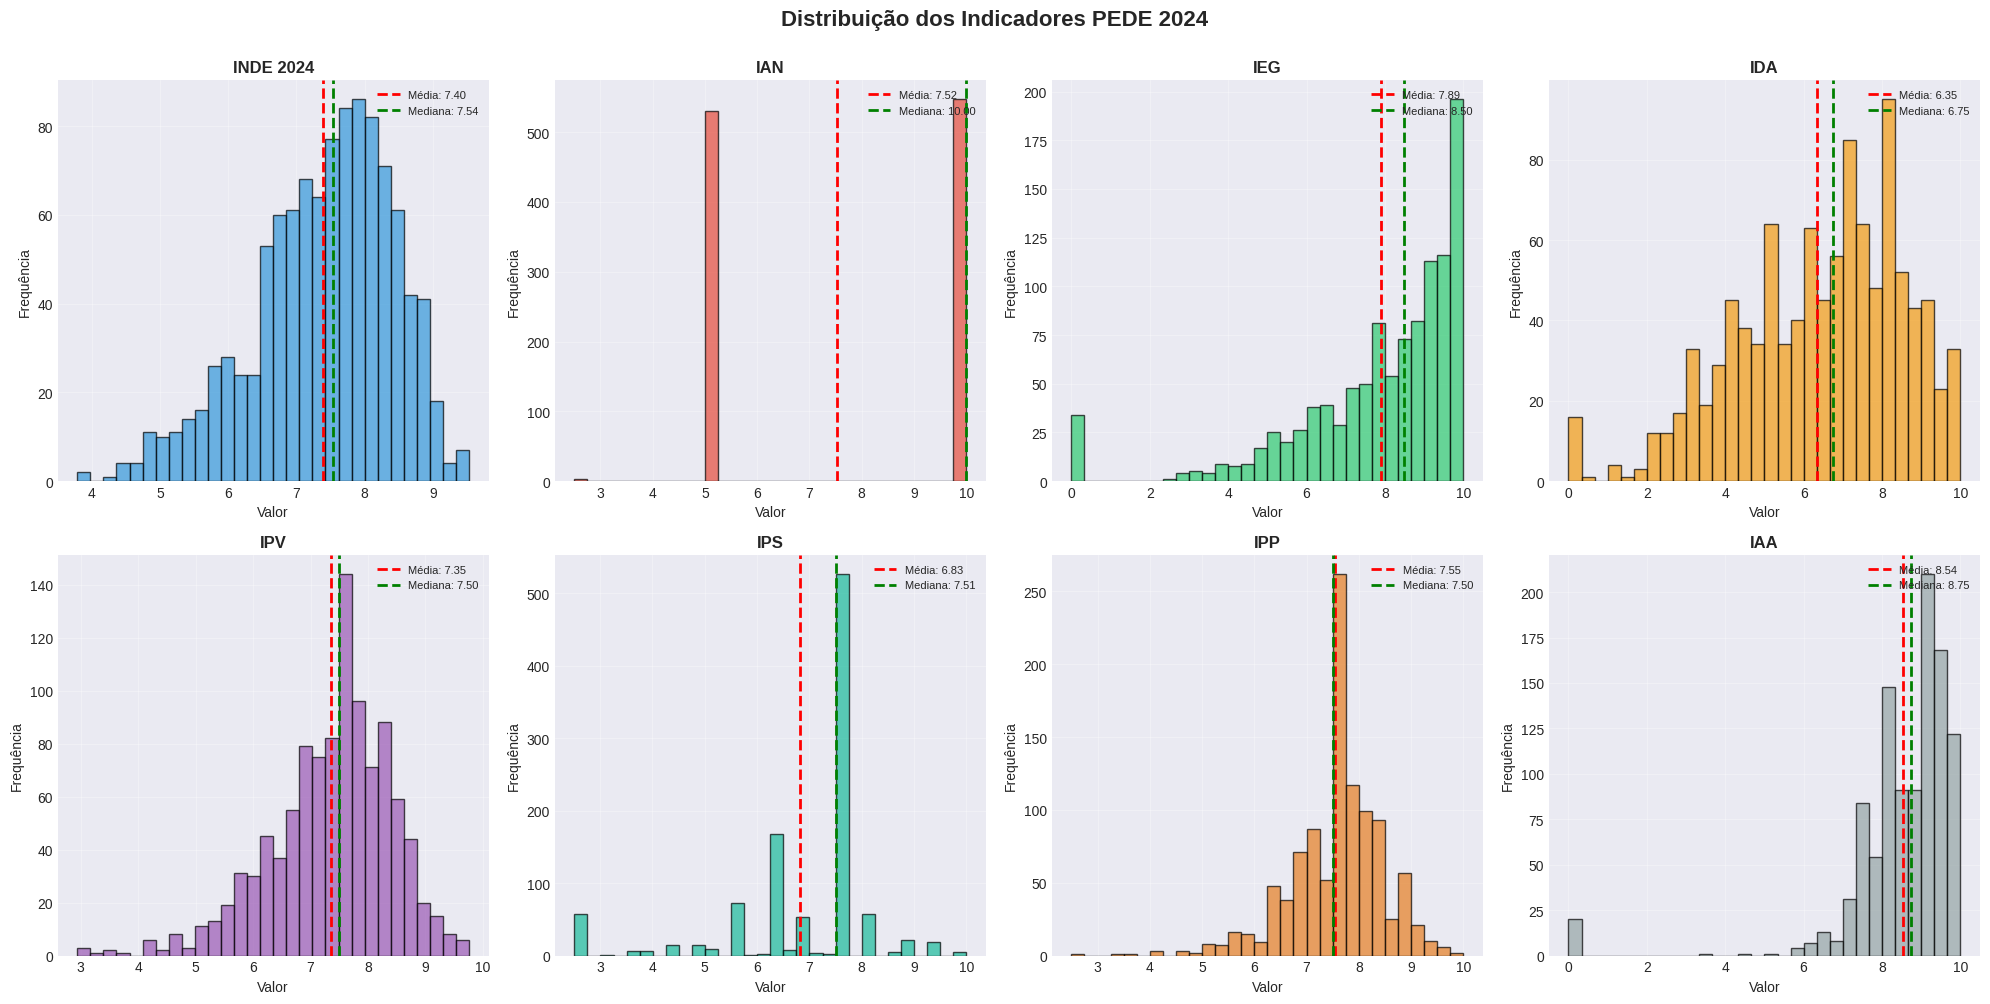

In [ ]:
# Visualização dos indicadores
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

colors_indicators = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12',
                     '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']

for idx, (ind, color) in enumerate(zip(indicadores, colors_indicators)):
    data = df_2024[ind].dropna()

    # Histograma
    axes[idx].hist(data, bins=30, color=color, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{ind}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Valor', fontsize=10)
    axes[idx].set_ylabel('Frequência', fontsize=10)
    axes[idx].grid(alpha=0.3)

    # Estatísticas no gráfico
    mean_val = data.mean()
    median_val = data.median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                     label=f'Média: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2,
                     label=f'Mediana: {median_val:.2f}')
    axes[idx].legend(fontsize=8, loc='upper right')

plt.suptitle('Distribuição dos Indicadores PEDE 2024', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 3.4. Correlação entre Indicadores e Defasagem

In [ ]:
print("="*80)
print("🔗 CORRELAÇÃO DOS INDICADORES COM A DEFASAGEM")
print("="*80)

# Calcular correlações
features_corr = indicadores + ['Idade', 'Ano ingresso', 'Nº Av']
correlacao_defasagem = df_2024[features_corr + ['Defasagem']].corr()['Defasagem'].sort_values(ascending=False)

print("\n📊 Correlações com Defasagem (ordenadas):")
print("\n" + "-"*50)
for feature, corr in correlacao_defasagem.items():
    if feature != 'Defasagem':
        direction = "↑" if corr > 0 else "↓"
        bar = "█" * int(abs(corr) * 40)
        print(f"{feature:15s}: {corr:+.4f} {direction} {bar}")
print("-"*50)

# Identificar top 3
top_3 = correlacao_defasagem.drop('Defasagem').abs().sort_values(ascending=False).head(3)
print("\n💡 TOP 3 INDICADORES MAIS CORRELACIONADOS:")
for i, (feature, corr_abs) in enumerate(top_3.items(), 1):
    corr_real = correlacao_defasagem[feature]
    print(f"   {i}. {feature}: {abs(corr_real):.4f} (correlação {'positiva' if corr_real > 0 else 'negativa'})")

🔗 CORRELAÇÃO DOS INDICADORES COM A DEFASAGEM

📊 Correlações com Defasagem (ordenadas):

--------------------------------------------------
IAN            : +0.8439 ↑ █████████████████████████████████
INDE 2024      : +0.3607 ↑ ██████████████
IPV            : +0.2324 ↑ █████████
IPP            : +0.1808 ↑ ███████
IDA            : +0.0971 ↑ ███
IPS            : +0.0517 ↑ ██
IAA            : +0.0333 ↑ █
IEG            : +0.0271 ↑ █
Idade          : +0.0097 ↑ 
Nº Av          : -0.0565 ↓ ██
Ano ingresso   : -0.2678 ↓ ██████████
--------------------------------------------------

💡 TOP 3 INDICADORES MAIS CORRELACIONADOS:
   1. IAN: 0.8439 (correlação positiva)
   2. INDE 2024: 0.3607 (correlação positiva)
   3. Ano ingresso: 0.2678 (correlação negativa)


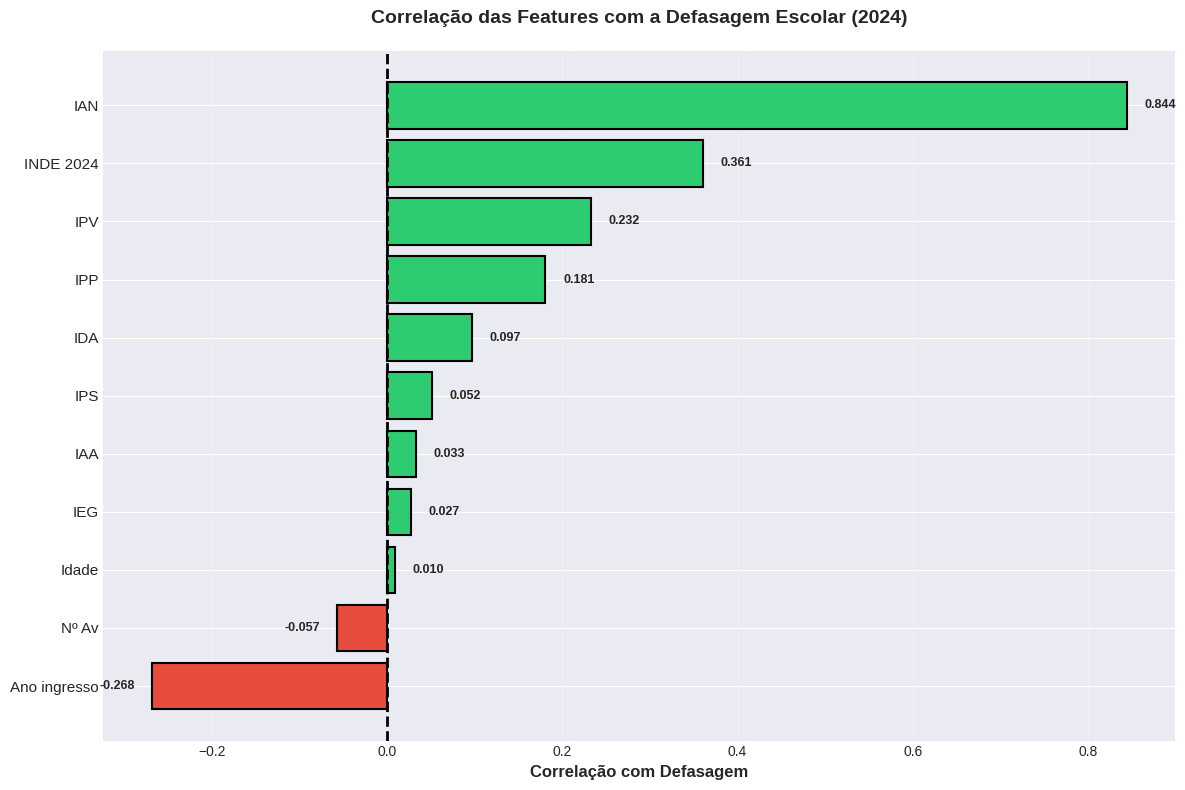


💡 INSIGHT PRINCIPAL:
   → IAN é o indicador MAIS IMPORTANTE para prever defasagem!
   → Correlação de 0.8439 indica forte relação.


In [ ]:
# Visualização da correlação
fig, ax = plt.subplots(figsize=(12, 8))

correlacao_plot = correlacao_defasagem.drop('Defasagem').sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlacao_plot.values]

bars = ax.barh(range(len(correlacao_plot)), correlacao_plot.values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(correlacao_plot)))
ax.set_yticklabels(correlacao_plot.index, fontsize=11)
ax.set_xlabel('Correlação com Defasagem', fontsize=12, fontweight='bold')
ax.set_title('Correlação das Features com a Defasagem Escolar (2024)', fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, (bar, val) in enumerate(zip(bars, correlacao_plot.values)):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, i, f'{val:.3f}', va='center', ha=ha, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT PRINCIPAL:")
print(f"   → {top_3.index[0]} é o indicador MAIS IMPORTANTE para prever defasagem!")
print(f"   → Correlação de {correlacao_defasagem[top_3.index[0]]:.4f} indica forte relação.")

### 3.5. Análise da Classificação "Pedra"

As **Pedras** categorizam os alunos baseado no INDE:
- **Quartzo**: 2.405 a 5.506 (nível inicial)
- **Ágata**: 5.506 a 6.868
- **Ametista**: 6.868 a 8.230
- **Topázio**: 8.230 a 9.294 (nível avançado)

In [ ]:
print("="*80)
print("💎 ANÁLISE DAS CLASSIFICAÇÕES PEDRA (2022-2024)")
print("="*80)

# Análise para cada ano
pedra_cols = ['Pedra 22', 'Pedra 2023', 'Pedra 2024']
dfs = [df_2022, df_2023, df_2024]

for ano, df, pedra_col in zip(anos, dfs, pedra_cols):
    print(f"\n📅 ANO {ano}:")
    pedra_counts = df[pedra_col].value_counts()
    print(pedra_counts)
    print(f"\n   Defasagem média por Pedra:")
    pedra_defasagem = df.groupby(pedra_col)['Defasagem'].mean().sort_values()
    for pedra, def_media in pedra_defasagem.items():
        print(f"   • {pedra}: {def_media:.2f} anos")

💎 ANÁLISE DAS CLASSIFICAÇÕES PEDRA (2022-2024)

📅 ANO 2022:
Pedra 22
Ametista    348
Ágata       249
Quartzo     131
Topázio     129
Name: count, dtype: int64

   Defasagem média por Pedra:
   • Quartzo: -1.47 anos
   • Ágata: -1.13 anos
   • Ametista: -0.84 anos
   • Topázio: -0.33 anos

📅 ANO 2023:
Pedra 2023
Ametista    237
Agata       144
Topázio     143
Quartzo      39
Name: count, dtype: int64

   Defasagem média por Pedra:
   • Quartzo: -1.26 anos
   • Agata: -1.12 anos
   • Ametista: -0.59 anos
   • Topázio: -0.31 anos

📅 ANO 2024:
Pedra 2024
Ametista    391
Topázio     326
Agata       225
Quartzo     112
Name: count, dtype: int64

   Defasagem média por Pedra:
   • Quartzo: -0.89 anos
   • Agata: -0.80 anos
   • Ametista: -0.56 anos
   • Topázio: -0.04 anos


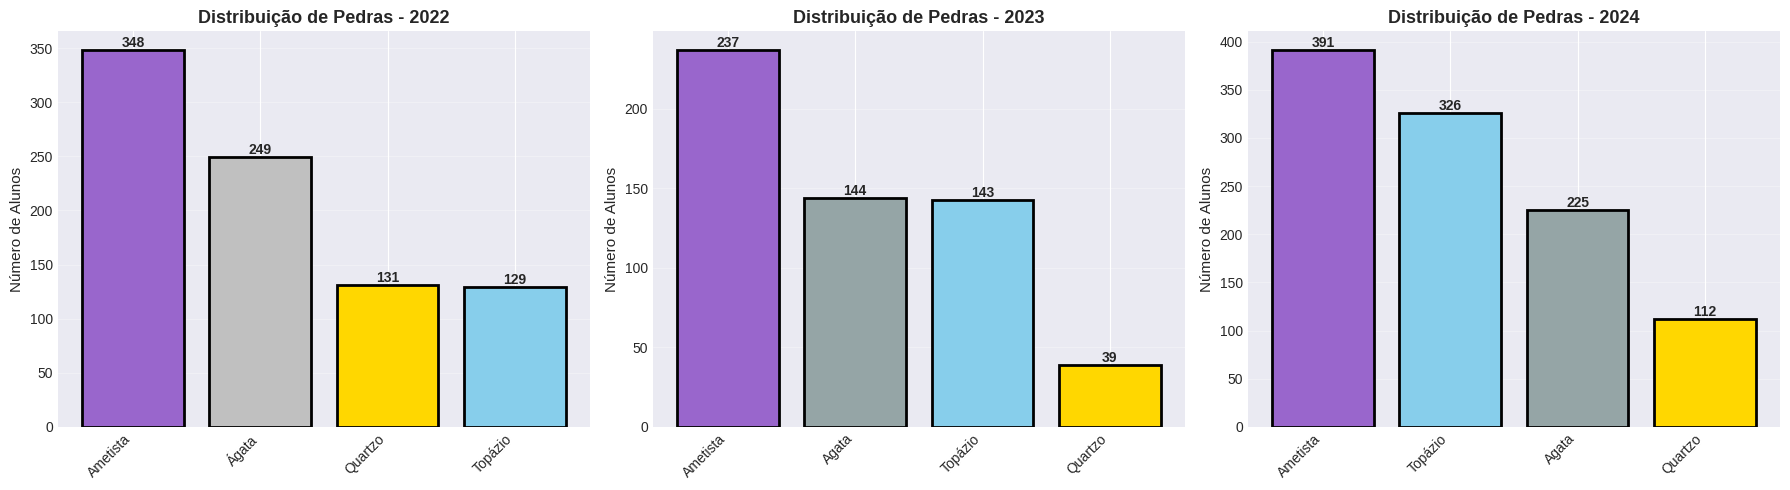

In [ ]:
# Visualização comparativa das Pedras
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pedra_colors = {'Quartzo': '#FFD700', 'Ágata': '#C0C0C0', 'Ametista': '#9966CC', 'Topázio': '#87CEEB'}

for idx, (ano, df, pedra_col) in enumerate(zip(anos, dfs, pedra_cols)):
    pedra_counts = df[pedra_col].value_counts()
    colors = [pedra_colors.get(p, '#95a5a6') for p in pedra_counts.index]

    bars = axes[idx].bar(range(len(pedra_counts)), pedra_counts.values,
                        color=colors, edgecolor='black', linewidth=2)
    axes[idx].set_xticks(range(len(pedra_counts)))
    axes[idx].set_xticklabels(pedra_counts.index, rotation=45, ha='right')
    axes[idx].set_title(f'Distribuição de Pedras - {ano}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Número de Alunos', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)

    # Valores nas barras
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.6. Análise Demográfica

In [ ]:
print("="*80)
print("ANÁLISE DEMOGRÁFICA - 2024")
print("="*80)

# Gênero
print("\nDistribuição por Gênero:")
genero_counts = df_2024['Gênero'].value_counts()
for genero, count in genero_counts.items():
    pct = count / len(df_2024) * 100
    print(f"   {genero}: {count} ({pct:.1f}%)")

# Idade
print("\nEstatísticas de Idade:")
print(f"   Média: {df_2024['Idade'].mean():.1f} anos")
print(f"   Mediana: {df_2024['Idade'].median():.0f} anos")
print(f"   Mínima: {df_2024['Idade'].min()} anos")
print(f"   Máxima: {df_2024['Idade'].max()} anos")

# Defasagem por gênero
print("\n Defasagem média por Gênero:")
for genero in genero_counts.index:
    def_media = df_2024[df_2024['Gênero'] == genero]['Defasagem'].mean()
    print(f"   {genero}: {def_media:.2f} anos")

# Tempo na instituição
df_2024['Tempo_PM'] = 2024 - df_2024['Ano ingresso']
print("\n Tempo na Passos Mágicos:")
print(f"   Média: {df_2024['Tempo_PM'].mean():.1f} anos")
print(f"   Mediana: {df_2024['Tempo_PM'].median():.0f} anos")
print(f"   Máximo: {df_2024['Tempo_PM'].max()} anos")

👥 ANÁLISE DEMOGRÁFICA - 2024

👫 Distribuição por Gênero:
   Feminino: 586 (54.2%)
   Masculino: 495 (45.8%)

📅 Estatísticas de Idade:
   Média: 12.4 anos
   Mediana: 12 anos
   Mínima: 7 anos
   Máxima: 19 anos

⚖️ Defasagem média por Gênero:
   Feminino: -0.44 anos
   Masculino: -0.51 anos

⏱️ Tempo na Passos Mágicos:
   Média: 1.4 anos
   Mediana: 1 anos
   Máximo: 3 anos


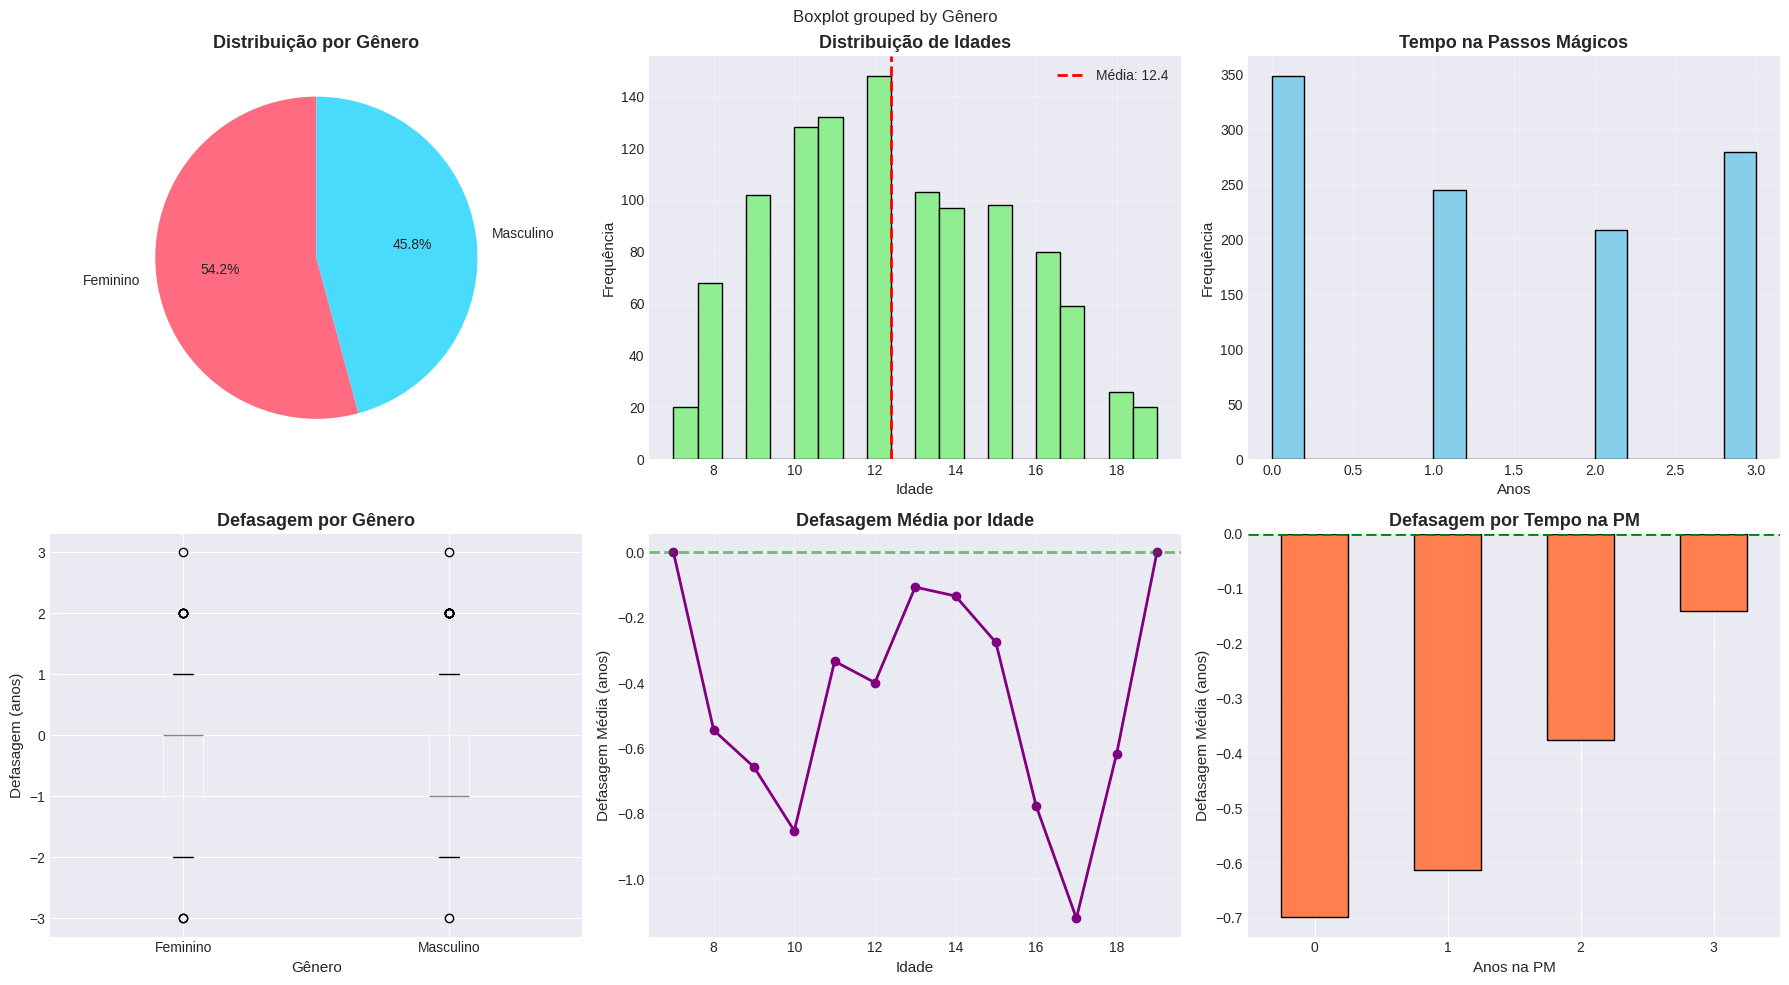

In [ ]:
# Visualizações demográficas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Gênero - Pizza
genero_counts.plot(kind='pie', ax=axes[0, 0], autopct='%1.1f%%',
                   startangle=90, colors=['#ff6b81', '#48dbfb'])
axes[0, 0].set_title('Distribuição por Gênero', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('')

# 2. Idade - Histograma
df_2024['Idade'].hist(bins=20, ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribuição de Idades', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Idade', fontsize=11)
axes[0, 1].set_ylabel('Frequência', fontsize=11)
axes[0, 1].axvline(df_2024['Idade'].mean(), color='red', linestyle='--',
                   linewidth=2, label=f"Média: {df_2024['Idade'].mean():.1f}")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Tempo na PM
df_2024['Tempo_PM'].hist(bins=15, ax=axes[0, 2], color='skyblue', edgecolor='black')
axes[0, 2].set_title('Tempo na Passos Mágicos', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('Anos', fontsize=11)
axes[0, 2].set_ylabel('Frequência', fontsize=11)
axes[0, 2].grid(alpha=0.3)

# 4. Defasagem por Gênero - Boxplot
df_2024.boxplot(column='Defasagem', by='Gênero', ax=axes[1, 0])
axes[1, 0].set_title('Defasagem por Gênero', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Gênero', fontsize=11)
axes[1, 0].set_ylabel('Defasagem (anos)', fontsize=11)
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# 5. Defasagem por Idade
idade_defasagem = df_2024.groupby('Idade')['Defasagem'].mean()
idade_defasagem.plot(kind='line', ax=axes[1, 1], marker='o', color='purple', linewidth=2, markersize=6)
axes[1, 1].set_title('Defasagem Média por Idade', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Idade', fontsize=11)
axes[1, 1].set_ylabel('Defasagem Média (anos)', fontsize=11)
axes[1, 1].axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5)
axes[1, 1].grid(alpha=0.3)

# 6. Defasagem por Tempo na PM
tempo_defasagem = df_2024.groupby('Tempo_PM')['Defasagem'].mean()
tempo_defasagem.plot(kind='bar', ax=axes[1, 2], color='coral', edgecolor='black')
axes[1, 2].set_title('Defasagem por Tempo na PM', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('Anos na PM', fontsize=11)
axes[1, 2].set_ylabel('Defasagem Média (anos)', fontsize=11)
axes[1, 2].axhline(y=0, color='green', linestyle='--', linewidth=2)
axes[1, 2].tick_params(axis='x', rotation=0)
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.7. Matriz de Correlação Completa

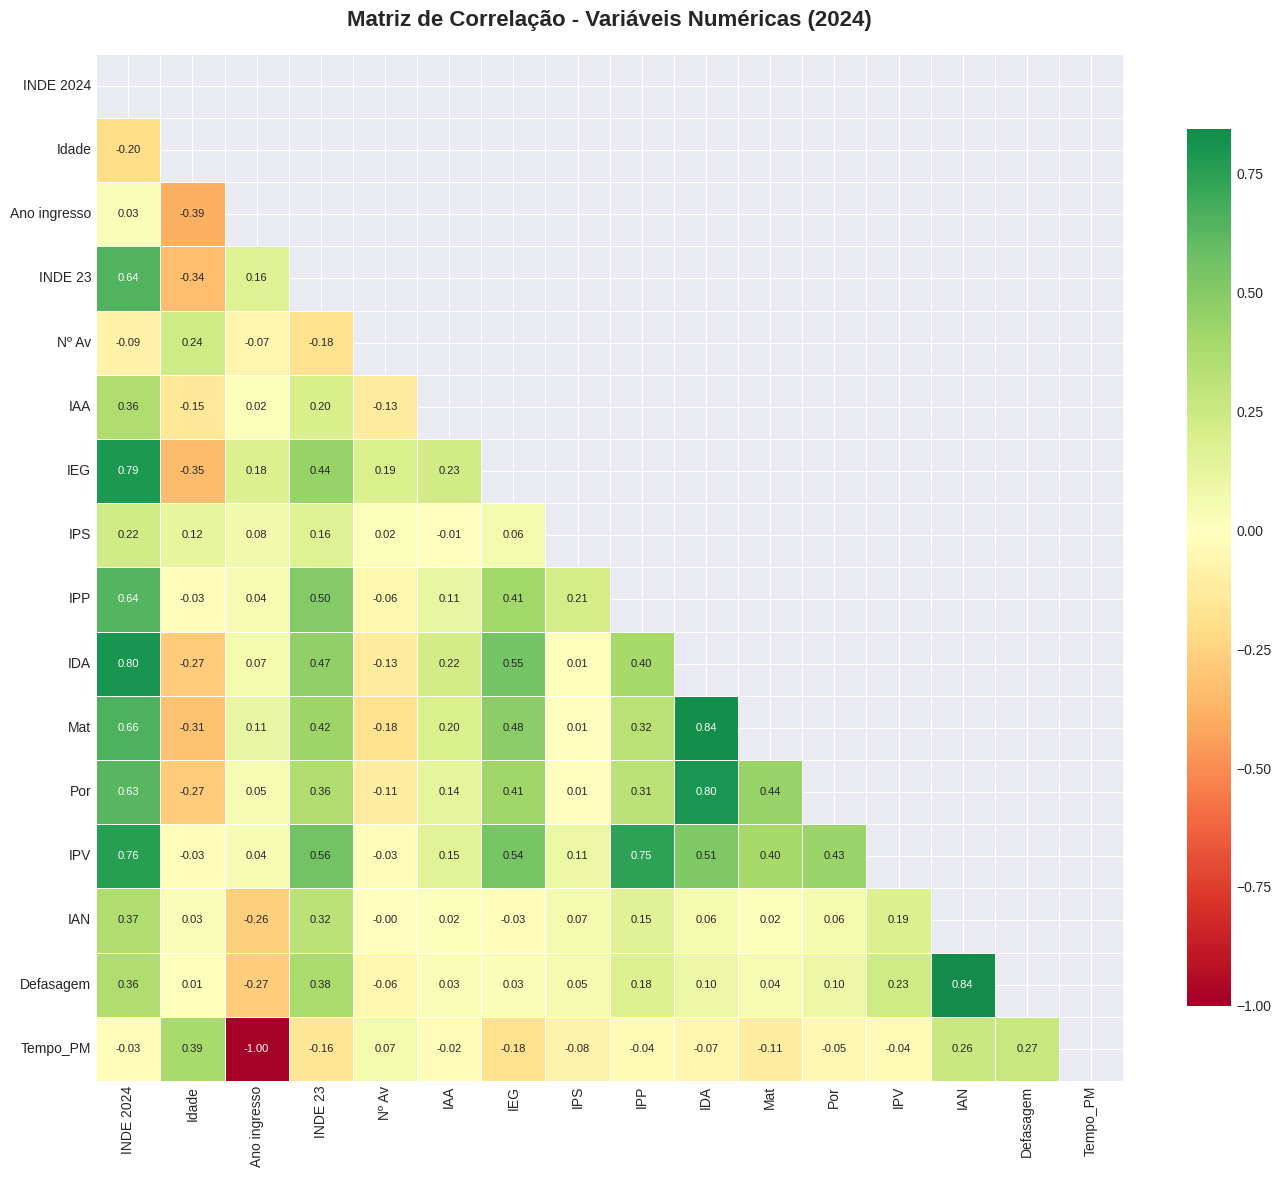

In [ ]:
# Selecionar colunas numéricas
numeric_cols = df_2024.select_dtypes(include=[np.number]).columns.tolist()

# Remover colunas com muitos NaN e colunas vazias
numeric_cols_clean = [
    col for col in numeric_cols
    if df_2024[col].notna().sum() > len(df_2024) * 0.5
]

# Calcular matriz de correlação
correlation_matrix = df_2024[numeric_cols_clean].corr()

# Visualização
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={'size': 8}
)
plt.title('Matriz de Correlação - Variáveis Numéricas (2024)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 🔧 4. Feature Engineering

Vamos criar novas features (variáveis) derivadas para melhorar o modelo.

In [ ]:
print("="*80)
print("FEATURE ENGINEERING - CRIANDO NOVAS VARIÁVEIS")
print("="*80)

# Trabalharemos com os dados de 2024 (mais completos)
df = df_2024.copy()

print(f"\n📊 Dataset inicial: {df.shape}")
print("\n✅ Criando novas features...\n")

# ─────────────────────────────────────────────────────────────
# 1. FEATURES TEMPORAIS
# ─────────────────────────────────────────────────────────────
df['Tempo_na_PM'] = 2024 - df['Ano ingresso']
print("   1. ✓ Tempo_na_PM: anos que o aluno está na instituição")

df['Idade_Ingresso'] = df['Idade'] - df['Tempo_na_PM']
print("   2. ✓ Idade_Ingresso: idade que o aluno tinha ao ingressar")

# ─────────────────────────────────────────────────────────────
# 2. FEATURES DE DESEMPENHO ACADÊMICO
# ─────────────────────────────────────────────────────────────
df['Media_Notas'] = df[['Mat', 'Por']].mean(axis=1)
print("   3. ✓ Media_Notas: média entre Matemática e Português")

df['Tem_Ingles'] = (~df['Ing'].isna()).astype(int)
print("   4. ✓ Tem_Ingles: se o aluno tem aulas de inglês (0/1)")

# Classificação Pedra como numérica
pedra_ordem = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}
df['Pedra_2024_num'] = df['Pedra 2024'].map(pedra_ordem)
df['Pedra_2023_num'] = df['Pedra 23'].map(pedra_ordem)
df['Pedra_2022_num'] = df['Pedra 22'].map(pedra_ordem)
df['Pedra_2021_num'] = df['Pedra 21'].map(pedra_ordem)
print("   5. ✓ Pedra_XXXX_num: classificação Pedra em escala numérica (1-4)")

# ─────────────────────────────────────────────────────────────
# 3. FEATURES DE EVOLUÇÃO TEMPORAL
# ─────────────────────────────────────────────────────────────
df['Evolucao_Pedra_23_24'] = df['Pedra_2024_num'] - df['Pedra_2023_num']
df['Evolucao_Pedra_22_23'] = df['Pedra_2023_num'] - df['Pedra_2022_num']
df['Evolucao_Pedra_21_22'] = df['Pedra_2022_num'] - df['Pedra_2021_num']
print("   6. ✓ Evolucao_Pedra_XX_XX: mudança na classificação entre anos")

# Evolução do INDE
if df['INDE 2024'].dtype == 'object':
    df['INDE 2024'] = pd.to_numeric(df['INDE 2024'].astype(str).str.replace(',', '.'), errors='coerce')

df['Evolucao_INDE_23_24'] = df['INDE 2024'] - df['INDE 23']
df['Evolucao_INDE_22_23'] = df['INDE 23'] - df['INDE 22']
print("   7. ✓ Evolucao_INDE_XX_XX: mudança no INDE entre anos")

# Taxa de evolução (percentual)
df['Taxa_Evolucao_INDE_23_24'] = ((df['INDE 2024'] - df['INDE 23']) / (df['INDE 23'] + 0.001)) * 100
print("   8. ✓ Taxa_Evolucao_INDE: variação percentual do INDE")

# ─────────────────────────────────────────────────────────────
# 4. FEATURES DE FASE/NÍVEL
# ─────────────────────────────────────────────────────────────
def extrair_numero_fase(fase):
    if pd.isna(fase):
        return np.nan
    if fase == 'ALFA':
        return 0
    try:
        return int(str(fase)[0])
    except:
        return np.nan

df['Fase_num'] = df['Fase'].apply(extrair_numero_fase)
df['Fase_Ideal_num'] = df['Fase Ideal'].apply(extrair_numero_fase)
df['Deficit_Fase'] = df['Fase_Ideal_num'] - df['Fase_num']
print("   9. ✓ Deficit_Fase: diferença entre fase ideal e fase atual")

# ─────────────────────────────────────────────────────────────
# 5. FEATURES DE INTERAÇÃO
# ─────────────────────────────────────────────────────────────
df['INDE_x_IAN'] = df['INDE 2024'] * df['IAN']
print("  10. ✓ INDE_x_IAN: interação multiplicativa entre INDE e IAN")

df['IDA_x_IEG'] = df['IDA'] * df['IEG']
print("  11. ✓ IDA_x_IEG: interação entre Aprendizagem e Engajamento")

df['Media_Notas_x_IAN'] = df['Media_Notas'] * df['IAN']
print("  12. ✓ Media_Notas_x_IAN: interação entre notas e adequação ao nível")

# ─────────────────────────────────────────────────────────────
# 6. FEATURES AGREGADAS
# ─────────────────────────────────────────────────────────────
# Média dos indicadores psico-educacionais
df['Media_Indicadores_Psico'] = df[['IPS', 'IPP', 'IAA']].mean(axis=1)
print("  13. ✓ Media_Indicadores_Psico: média de IPS, IPP e IAA")

# Média dos indicadores de desempenho
df['Media_Indicadores_Desemp'] = df[['IDA', 'IEG', 'IPV']].mean(axis=1)
print("  14. ✓ Media_Indicadores_Desemp: média de IDA, IEG e IPV")

# ─────────────────────────────────────────────────────────────
# 7. FEATURES BINÁRIAS E CATEGÓRICAS
# ─────────────────────────────────────────────────────────────
df['Genero_bin'] = (df['Gênero'] == 'Menino').astype(int)
print("  15. ✓ Genero_bin: 1=Menino, 0=Menina")

df['Veterano'] = (df['Tempo_na_PM'] >= 2).astype(int)
print("  16. ✓ Veterano: se está há 2+ anos na instituição")

df['Faixa_Etaria'] = pd.cut(df['Idade'], bins=[0, 10, 13, 16, 100],
                            labels=['Criança', 'Pré-adolescente', 'Adolescente', 'Jovem'])
print("  17. ✓ Faixa_Etaria: categorização da idade")

# ─────────────────────────────────────────────────────────────
# 8. FEATURES DE TENDÊNCIA
# ─────────────────────────────────────────────────────────────
# Tendência de melhora (considerando evolução de Pedras)
df['Tendencia_Melhora'] = (
    (df['Evolucao_Pedra_23_24'].fillna(0) > 0).astype(int) +
    (df['Evolucao_Pedra_22_23'].fillna(0) > 0).astype(int)
)
print("  18. ✓ Tendencia_Melhora: quantidade de anos com evolução positiva")

# ─────────────────────────────────────────────────────────────
# 9. FEATURES DE CONSISTÊNCIA
# ─────────────────────────────────────────────────────────────
# Desvio padrão das notas (variabilidade no desempenho)
df['Variabilidade_Notas'] = df[['Mat', 'Por']].std(axis=1)
print("  19. ✓ Variabilidade_Notas: desvio padrão entre as notas")

print(f"\n✅ Feature Engineering concluído!")
print(f"   Total de colunas agora: {df.shape[1]}")
print(f"   Features criadas: {df.shape[1] - df_2024.shape[1]}")

🔧 FEATURE ENGINEERING - CRIANDO NOVAS VARIÁVEIS

📊 Dataset inicial: (1081, 51)

✅ Criando novas features...

   1. ✓ Tempo_na_PM: anos que o aluno está na instituição
   2. ✓ Idade_Ingresso: idade que o aluno tinha ao ingressar
   3. ✓ Media_Notas: média entre Matemática e Português
   4. ✓ Tem_Ingles: se o aluno tem aulas de inglês (0/1)
   5. ✓ Pedra_XXXX_num: classificação Pedra em escala numérica (1-4)
   6. ✓ Evolucao_Pedra_XX_XX: mudança na classificação entre anos
   7. ✓ Evolucao_INDE_XX_XX: mudança no INDE entre anos
   8. ✓ Taxa_Evolucao_INDE: variação percentual do INDE
   9. ✓ Deficit_Fase: diferença entre fase ideal e fase atual
  10. ✓ INDE_x_IAN: interação multiplicativa entre INDE e IAN
  11. ✓ IDA_x_IEG: interação entre Aprendizagem e Engajamento
  12. ✓ Media_Notas_x_IAN: interação entre notas e adequação ao nível
  13. ✓ Media_Indicadores_Psico: média de IPS, IPP e IAA
  14. ✓ Media_Indicadores_Desemp: média de IDA, IEG e IPV
  15. ✓ Genero_bin: 1=Menino, 0=Menina
  

## 🎯 5. Preparação dos Dados para Modelagem

Agora vamos preparar os dados para treinar nosso modelo de Machine Learning.

### 5.1. Seleção de Features

Vamos selecionar as features mais relevantes baseado em:
1. Correlação com o target
2. Importância teórica (conhecimento do domínio)
3. Features engenheiradas que criamos

In [ ]:
print("="*80)
print("🎯 SELEÇÃO DE FEATURES PARA O MODELO")
print("="*80)

# Lista completa de features numéricas
numeric_features = [
    # ─── INDICADORES PEDE (CORE) ───
    'IAN',           # (correlação forte com target)
    'INDE 2024',     # Índice de Desenvolvimento Educacional
    'IEG',           # Engajamento
    'IDA',           # Aprendizagem
    'IPV',           # Ponto de Virada
    'IPS',           # Psicossocial
    'IPP',           # Psicopedagógico
    'IAA',           # Auto-avaliação

    # ─── NOTAS E DESEMPENHO ───
    'Media_Notas',
    'Mat',
    'Por',
    'Variabilidade_Notas',

    # ─── CLASSIFICAÇÃO PEDRA ───
    'Pedra_2024_num',
    'Pedra_2023_num',
    'Pedra_2022_num',

    # ─── TEMPORAIS E DEMOGRÁFICAS ───
    'Idade',
    'Tempo_na_PM',
    'Idade_Ingresso',
    'Fase_num',

    # ─── FEATURES ENGENHEIRADAS ───
    'Deficit_Fase',              # Diferença fase ideal vs real
    'INDE_x_IAN',               # Interação importante
    'IDA_x_IEG',
    'Media_Notas_x_IAN',
    'Evolucao_Pedra_23_24',
    'Evolucao_INDE_23_24',
    'Taxa_Evolucao_INDE_23_24',
    'Media_Indicadores_Psico',
    'Media_Indicadores_Desemp',
    'Tendencia_Melhora',
    'Nº Av',                    # Número de avaliações

    # ─── FEATURES BINÁRIAS ───
    'Genero_bin',
    'Tem_Ingles',
    'Veterano'
]

# Verificar quais features existem
numeric_features = [f for f in numeric_features if f in df.columns]

print(f"\n📊 Total de features selecionadas: {len(numeric_features)}")
print("\n📋 Lista de features:")
for i, feat in enumerate(numeric_features, 1):
    print(f"   {i:2d}. {feat}")

# Target
target = 'Defasagem'
print(f"\n🎯 Variável Target: {target}")
print(f"   Classes únicas: {sorted(df[target].unique())}")

🎯 SELEÇÃO DE FEATURES PARA O MODELO

📊 Total de features selecionadas: 33

📋 Lista de features:
    1. IAN
    2. INDE 2024
    3. IEG
    4. IDA
    5. IPV
    6. IPS
    7. IPP
    8. IAA
    9. Media_Notas
   10. Mat
   11. Por
   12. Variabilidade_Notas
   13. Pedra_2024_num
   14. Pedra_2023_num
   15. Pedra_2022_num
   16. Idade
   17. Tempo_na_PM
   18. Idade_Ingresso
   19. Fase_num
   20. Deficit_Fase
   21. INDE_x_IAN
   22. IDA_x_IEG
   23. Media_Notas_x_IAN
   24. Evolucao_Pedra_23_24
   25. Evolucao_INDE_23_24
   26. Taxa_Evolucao_INDE_23_24
   27. Media_Indicadores_Psico
   28. Media_Indicadores_Desemp
   29. Tendencia_Melhora
   30. Nº Av
   31. Genero_bin
   32. Tem_Ingles
   33. Veterano

🎯 Variável Target: Defasagem
   Classes únicas: [np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### 5.2. Tratamento de Valores Faltantes

In [ ]:
print("="*80)
print("🔧 TRATAMENTO DE VALORES FALTANTES")
print("="*80)

# Verificar valores faltantes ANTES
missing_before = df[numeric_features].isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("\n📊 Valores faltantes ANTES do tratamento:")
if len(missing_before) > 0:
    print(f"\n{'Feature':<30} {'Faltantes':>10} {'%':>8}")
    print("-" * 50)
    for feat, count in missing_before.items():
        pct = count / len(df) * 100
        print(f"{feat:<30} {count:>10} {pct:>7.1f}%")
else:
    print("   ✅ Nenhum valor faltante!")

# Preencher com mediana
print("\n🔄 Preenchendo valores faltantes com a mediana...")
for col in numeric_features:
    if df[col].isna().any():
        median_val = df[col].median()
        if pd.isna(median_val):  # Se mediana for NaN, usar 0
            median_val = 0
        df[col].fillna(median_val, inplace=True)

    # Remover infinitos
    df[col].replace([np.inf, -np.inf], 0, inplace=True)

# Verificar DEPOIS
missing_after = df[numeric_features].isnull().sum()
missing_after = missing_after[missing_after > 0]

print("\n Tratamento concluído!")
print(f"\nValores faltantes DEPOIS do tratamento: {len(missing_after)}")
if len(missing_after) == 0:
    print("Todos os valores faltantes foram tratados!")

🔧 TRATAMENTO DE VALORES FALTANTES

📊 Valores faltantes ANTES do tratamento:

Feature                         Faltantes        %
--------------------------------------------------
Deficit_Fase                         1081   100.0%
Evolucao_Pedra_23_24                  639    59.1%
Pedra_2022_num                        616    57.0%
Pedra_2023_num                        548    50.7%
Taxa_Evolucao_INDE_23_24              403    37.3%
Evolucao_INDE_23_24                   403    37.3%
Pedra_2024_num                        252    23.3%
Variabilidade_Notas                    36     3.3%
Por                                    32     3.0%
Mat                                    31     2.9%
INDE 2024                              27     2.5%
IPV                                    27     2.5%
IDA                                    27     2.5%
IPP                                    27     2.5%
IPS                                    27     2.5%
Media_Notas                            27     2.5%
IAA  

### 5.3. Preparação Final dos Dados

In [ ]:
# Preparar X e y
X = df[numeric_features].copy()
y = df[target].copy()

print("="*80)
print("📦 DADOS PREPARADOS PARA MODELAGEM")
print("="*80)
print(f"\n✅ X (features): {X.shape}")
print(f"✅ y (target): {y.shape}")
print(f"\n📊 Verificação final:")
print(f"   • Valores NaN em X: {X.isna().sum().sum()}")
print(f"   • Valores NaN em y: {y.isna().sum()}")
print(f"   • Total de amostras: {len(X)}")
print(f"   • Total de features: {X.shape[1]}")
print(f"\n📊 Distribuição do target:")
print(y.value_counts().sort_index())

📦 DADOS PREPARADOS PARA MODELAGEM

✅ X (features): (1081, 33)
✅ y (target): (1081,)

📊 Verificação final:
   • Valores NaN em X: 0
   • Valores NaN em y: 0
   • Total de amostras: 1081
   • Total de features: 33

📊 Distribuição do target:
Defasagem
-3      3
-2     90
-1    441
 0    448
 1     81
 2     16
 3      2
Name: count, dtype: int64


### 5.4. Divisão Treino/Teste e Normalização

In [ ]:
print("="*80)
print("✂️ DIVISÃO TREINO/TESTE E NORMALIZAÇÃO")
print("="*80)

# Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None  # Não usar stratify devido a classes raras
)

print(f"\n📊 Divisão dos dados (80/20):")
print(f"   • Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   • Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n📈 Distribuição do target - TREINO:")
train_dist = y_train.value_counts().sort_index()
for val, count in train_dist.items():
    pct = count / len(y_train) * 100
    print(f"   Defasagem {val:+2d}: {count:4d} ({pct:5.1f}%)")

print(f"\n📈 Distribuição do target - TESTE:")
test_dist = y_test.value_counts().sort_index()
for val, count in test_dist.items():
    pct = count / len(y_test) * 100
    print(f"   Defasagem {val:+2d}: {count:4d} ({pct:5.1f}%)")

# Normalizar os dados (StandardScaler)
print(f"\n🔧 Normalizando dados com StandardScaler...")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"✅ Normalização concluída!")


✂️ DIVISÃO TREINO/TESTE E NORMALIZAÇÃO

📊 Divisão dos dados (80/20):
   • Treino: 864 amostras (79.9%)
   • Teste:  217 amostras (20.1%)

📈 Distribuição do target - TREINO:
   Defasagem -3:    3 (  0.3%)
   Defasagem -2:   82 (  9.5%)
   Defasagem -1:  347 ( 40.2%)
   Defasagem +0:  357 ( 41.3%)
   Defasagem +1:   66 (  7.6%)
   Defasagem +2:    8 (  0.9%)
   Defasagem +3:    1 (  0.1%)

📈 Distribuição do target - TESTE:
   Defasagem -2:    8 (  3.7%)
   Defasagem -1:   94 ( 43.3%)
   Defasagem +0:   91 ( 41.9%)
   Defasagem +1:   15 (  6.9%)
   Defasagem +2:    8 (  3.7%)
   Defasagem +3:    1 (  0.5%)

🔧 Normalizando dados com StandardScaler...
✅ Normalização concluída!


## 🤖 6. Treinamento dos Modelos

1. **Logistic Regression** - baseline simples e interpretável
2. **Decision Tree** - modelo baseado em árvore (fácil de visualizar)
3. **Random Forest** - ensemble de árvores de decisão
4. **Gradient Boosting** - boosting sequencial (geralmente o melhor)

### 📊 Métricas de Avaliação

Para cada modelo, avaliaremos:
- **Acurácia**: % de predições corretas
- **F1-Score (weighted)**: média harmônica de precision e recall (melhor para dados desbalanceados)
- **F1-Score (macro)**: média simples entre classes
- **MAE (Mean Absolute Error)**: erro médio em anos de defasagem
- **Cohen's Kappa**: concordância ajustada pelo acaso (0=acaso, 1=perfeito)

### ⚙️ Por que múltiplos modelos?

- **Comparação**: Identificar qual algoritmo funciona melhor para este problema específico
- **Robustez**: Verificar se diferentes abordagens convergem para resultados similares
- **Ensemble**: Possibilidade de combinar modelos para melhor performance

### 6.1. Modelo 1: Logistic Regression (Baseline)


In [ ]:
print("="*80)
print("📊 MODELO 1: LOGISTIC REGRESSION (BASELINE)")
print("="*80)

print("\n🔄 Treinando Logistic Regression...")

# Inicializar modelo
lr = LogisticRegression(
    max_iter=1000,              # Máximo de iterações
    class_weight='balanced',    # Balancear classes desbalanceadas
    random_state=42,            # Reprodutibilidade
    multi_class='multinomial',  # Multinomial para múltiplas classes
    solver='lbfgs'             # Solver eficiente
)

# Treinar
lr.fit(X_train_scaled, y_train)

# Predições
y_pred_lr = lr.predict(X_test_scaled)
y_pred_proba_lr = lr.predict_proba(X_test_scaled)

# Métricas
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_weighted_lr = f1_score(y_test, y_pred_lr, average='weighted')
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro')
mae_lr = mean_absolute_error(y_test, y_pred_lr)
kappa_lr = cohen_kappa_score(y_test, y_pred_lr)

print(f"\n✅ Treinamento concluído!")
print(f"\n{'='*60}")
print(f"📊 MÉTRICAS - LOGISTIC REGRESSION")
print(f"{'='*60}")
print(f"Acurácia:              {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"F1-Score (weighted):   {f1_weighted_lr:.4f}")
print(f"F1-Score (macro):      {f1_macro_lr:.4f}")
print(f"MAE (erro médio):      {mae_lr:.4f} anos")
print(f"Cohen's Kappa:         {kappa_lr:.4f}")
print(f"{'='*60}")

print(f"\n📋 Relatório de Classificação:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

📊 MODELO 1: LOGISTIC REGRESSION (BASELINE)

🔄 Treinando Logistic Regression...

✅ Treinamento concluído!

📊 MÉTRICAS - LOGISTIC REGRESSION
Acurácia:              0.8249 (82.49%)
F1-Score (weighted):   0.8550
F1-Score (macro):      0.7571
MAE (erro médio):      0.1751 anos
Cohen's Kappa:         0.7432

📋 Relatório de Classificação:
              precision    recall  f1-score   support

          -2       0.24      0.88      0.38         8
          -1       0.99      0.77      0.86        94
           0       0.99      0.89      0.94        91
           1       0.50      0.80      0.62        15
           2       0.75      0.75      0.75         8
           3       1.00      1.00      1.00         1

    accuracy                           0.82       217
   macro avg       0.74      0.85      0.76       217
weighted avg       0.92      0.82      0.85       217



### 6.2. Modelo 2: Decision Tree


In [ ]:
print("="*80)
print("🌳 MODELO 2: DECISION TREE")
print("="*80)

print("\n🔄 Treinando Decision Tree...")

# Inicializar modelo
dt = DecisionTreeClassifier(
    max_depth=15,              # Profundidade máxima da árvore
    min_samples_split=10,      # Mínimo de amostras para dividir nó
    min_samples_leaf=5,        # Mínimo de amostras em folha
    class_weight='balanced',   # Balancear classes
    random_state=42
)

# Treinar
dt.fit(X_train_scaled, y_train)

# Predições
y_pred_dt = dt.predict(X_test_scaled)
y_pred_proba_dt = dt.predict_proba(X_test_scaled)

# Métricas
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_weighted_dt = f1_score(y_test, y_pred_dt, average='weighted')
f1_macro_dt = f1_score(y_test, y_pred_dt, average='macro')
mae_dt = mean_absolute_error(y_test, y_pred_dt)
kappa_dt = cohen_kappa_score(y_test, y_pred_dt)

print(f"\n✅ Treinamento concluído!")
print(f"\n{'='*60}")
print(f"📊 MÉTRICAS - DECISION TREE")
print(f"{'='*60}")
print(f"Acurácia:              {acc_dt:.4f} ({acc_dt*100:.2f}%)")
print(f"F1-Score (weighted):   {f1_weighted_dt:.4f}")
print(f"F1-Score (macro):      {f1_macro_dt:.4f}")
print(f"MAE (erro médio):      {mae_dt:.4f} anos")
print(f"Cohen's Kappa:         {kappa_dt:.4f}")
print(f"{'='*60}")

print(f"\n📋 Relatório de Classificação:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

🌳 MODELO 2: DECISION TREE

🔄 Treinando Decision Tree...

✅ Treinamento concluído!

📊 MÉTRICAS - DECISION TREE
Acurácia:              0.7742 (77.42%)
F1-Score (weighted):   0.8095
F1-Score (macro):      0.4452
MAE (erro médio):      0.2350 anos
Cohen's Kappa:         0.6673

📋 Relatório de Classificação:
              precision    recall  f1-score   support

          -3       0.00      0.00      0.00         0
          -2       0.18      0.50      0.27         8
          -1       0.95      0.80      0.87        94
           0       0.96      0.81      0.88        91
           1       0.32      0.67      0.43        15
           2       0.71      0.62      0.67         8
           3       0.00      0.00      0.00         1

    accuracy                           0.77       217
   macro avg       0.45      0.49      0.45       217
weighted avg       0.87      0.77      0.81       217



### 6.3. Modelo 3: Random Forest


In [ ]:
print("="*80)
print("🌲 MODELO 3: RANDOM FOREST")
print("="*80)

print("\n🔄 Treinando Random Forest...")

# Inicializar modelo
rf = RandomForestClassifier(
    n_estimators=200,          # Número de árvores
    max_depth=15,              # Profundidade máxima
    min_samples_split=5,       # Mínimo para dividir
    min_samples_leaf=2,        # Mínimo em folha
    class_weight='balanced',   # Balancear classes
    random_state=42,
    n_jobs=-1                  # Usar todos os cores
)

# Treinar
rf.fit(X_train_scaled, y_train)

# Predições
y_pred_rf = rf.predict(X_test_scaled)
y_pred_proba_rf = rf.predict_proba(X_test_scaled)

# Métricas
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
mae_rf = mean_absolute_error(y_test, y_pred_rf)
kappa_rf = cohen_kappa_score(y_test, y_pred_rf)

print(f"\n✅ Treinamento concluído!")
print(f"\n{'='*60}")
print(f"📊 MÉTRICAS - RANDOM FOREST")
print(f"{'='*60}")
print(f"Acurácia:              {acc_rf:.4f} ({acc_rf*100:.2f}%)")
print(f"F1-Score (weighted):   {f1_weighted_rf:.4f}")
print(f"F1-Score (macro):      {f1_macro_rf:.4f}")
print(f"MAE (erro médio):      {mae_rf:.4f} anos")
print(f"Cohen's Kappa:         {kappa_rf:.4f}")
print(f"{'='*60}")

print(f"\n📋 Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

🌲 MODELO 3: RANDOM FOREST

🔄 Treinando Random Forest...

✅ Treinamento concluído!

📊 MÉTRICAS - RANDOM FOREST
Acurácia:              0.8618 (86.18%)
F1-Score (weighted):   0.8421
F1-Score (macro):      0.5005
MAE (erro médio):      0.1659 anos
Cohen's Kappa:         0.7703

📋 Relatório de Classificação:
              precision    recall  f1-score   support

          -2       0.17      0.12      0.14         8
          -1       0.92      0.95      0.93        94
           0       0.86      0.98      0.91        91
           1       0.80      0.27      0.40        15
           2       0.80      0.50      0.62         8
           3       0.00      0.00      0.00         1

    accuracy                           0.86       217
   macro avg       0.59      0.47      0.50       217
weighted avg       0.85      0.86      0.84       217



### 6.4. Modelo 4: Gradient Boosting



In [ ]:
print("="*80)
print("🚀 MODELO 4: GRADIENT BOOSTING")
print("="*80)

print("\n🔄 Treinando Gradient Boosting...")

# Inicializar modelo
gb = GradientBoostingClassifier(
    n_estimators=200,          # Número de árvores
    learning_rate=0.05,        # Taxa de aprendizado
    max_depth=5,               # Profundidade máxima
    min_samples_split=5,       # Mínimo para dividir
    subsample=0.8,             # Subsampling para reduzir overfitting
    random_state=42
)

# Treinar
gb.fit(X_train_scaled, y_train)

# Predições
y_pred_gb = gb.predict(X_test_scaled)
y_pred_proba_gb = gb.predict_proba(X_test_scaled)

# Métricas
acc_gb = accuracy_score(y_test, y_pred_gb)
f1_weighted_gb = f1_score(y_test, y_pred_gb, average='weighted')
f1_macro_gb = f1_score(y_test, y_pred_gb, average='macro')
mae_gb = mean_absolute_error(y_test, y_pred_gb)
kappa_gb = cohen_kappa_score(y_test, y_pred_gb)

print(f"\n✅ Treinamento concluído!")
print(f"\n{'='*60}")
print(f"📊 MÉTRICAS - GRADIENT BOOSTING")
print(f"{'='*60}")
print(f"Acurácia:              {acc_gb:.4f} ({acc_gb*100:.2f}%)")
print(f"F1-Score (weighted):   {f1_weighted_gb:.4f}")
print(f"F1-Score (macro):      {f1_macro_gb:.4f}")
print(f"MAE (erro médio):      {mae_gb:.4f} anos")
print(f"Cohen's Kappa:         {kappa_gb:.4f}")
print(f"{'='*60}")

print(f"\n📋 Relatório de Classificação:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

🚀 MODELO 4: GRADIENT BOOSTING

🔄 Treinando Gradient Boosting...

✅ Treinamento concluído!

📊 MÉTRICAS - GRADIENT BOOSTING
Acurácia:              0.8525 (85.25%)
F1-Score (weighted):   0.8400
F1-Score (macro):      0.5111
MAE (erro médio):      0.1659 anos
Cohen's Kappa:         0.7594

📋 Relatório de Classificação:
              precision    recall  f1-score   support

          -2       0.18      0.25      0.21         8
          -1       0.93      0.90      0.92        94
           0       0.87      0.99      0.92        91
           1       0.60      0.20      0.30        15
           2       0.83      0.62      0.71         8
           3       0.00      0.00      0.00         1

    accuracy                           0.85       217
   macro avg       0.57      0.49      0.51       217
weighted avg       0.85      0.85      0.84       217



### 7.1. Tabela Comparativa de Métricas

In [ ]:
print("="*80)
print("📊 COMPARAÇÃO DE TODOS OS MODELOS")
print("="*80)

# Criar DataFrame de comparação
results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Acurácia': [acc_lr, acc_dt, acc_rf, acc_gb],
    'F1-Score (weighted)': [f1_weighted_lr, f1_weighted_dt, f1_weighted_rf, f1_weighted_gb],
    'F1-Score (macro)': [f1_macro_lr, f1_macro_dt, f1_macro_rf, f1_macro_gb],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_gb],
    "Cohen's Kappa": [kappa_lr, kappa_dt, kappa_rf, kappa_gb]
})

# Ordenar por F1-Score weighted
results = results.sort_values('F1-Score (weighted)', ascending=False).reset_index(drop=True)

print("\n📈 Tabela Comparativa (ordenada por F1-Score):")
print("\n" + results.to_string(index=False))

# Identificar melhor modelo
best_model_name = results.loc[0, 'Modelo']
best_f1 = results.loc[0, 'F1-Score (weighted)']

print(f"\n\n{'='*80}")
print(f"MELHOR MODELO: {best_model_name}")
print(f"{'='*80}")
print(f"F1-Score (weighted): {best_f1:.4f}")
print(f"Acurácia: {results.loc[0, 'Acurácia']:.4f}")
print(f"MAE: {results.loc[0, 'MAE']:.4f} anos")
print(f"{'='*80}")

# Definir melhor modelo
if best_model_name == 'Logistic Regression':
    best_model = lr
    y_pred_best = y_pred_lr
elif best_model_name == 'Decision Tree':
    best_model = dt
    y_pred_best = y_pred_dt
elif best_model_name == 'Random Forest':
    best_model = rf
    y_pred_best = y_pred_rf
else:
    best_model = gb
    y_pred_best = y_pred_gb

📊 COMPARAÇÃO DE TODOS OS MODELOS

📈 Tabela Comparativa (ordenada por F1-Score):

             Modelo  Acurácia  F1-Score (weighted)  F1-Score (macro)  MAE  Cohen's Kappa
Logistic Regression      0.82                 0.85              0.76 0.18           0.74
      Random Forest      0.86                 0.84              0.50 0.17           0.77
  Gradient Boosting      0.85                 0.84              0.51 0.17           0.76
      Decision Tree      0.77                 0.81              0.45 0.24           0.67


🏆 MELHOR MODELO: Logistic Regression
   F1-Score (weighted): 0.8550
   Acurácia: 0.8249
   MAE: 0.1751 anos


## 📊 7. Comparação e Análise dos Modelos

#### ⚠️ - Quando eu não restringi a base por idade e usei todos os anos sem limitar menores de 19 anos, o melhor modelo para prever foi o Random Forest

📈 SEÇÃO 7.2: Visualização Comparativa

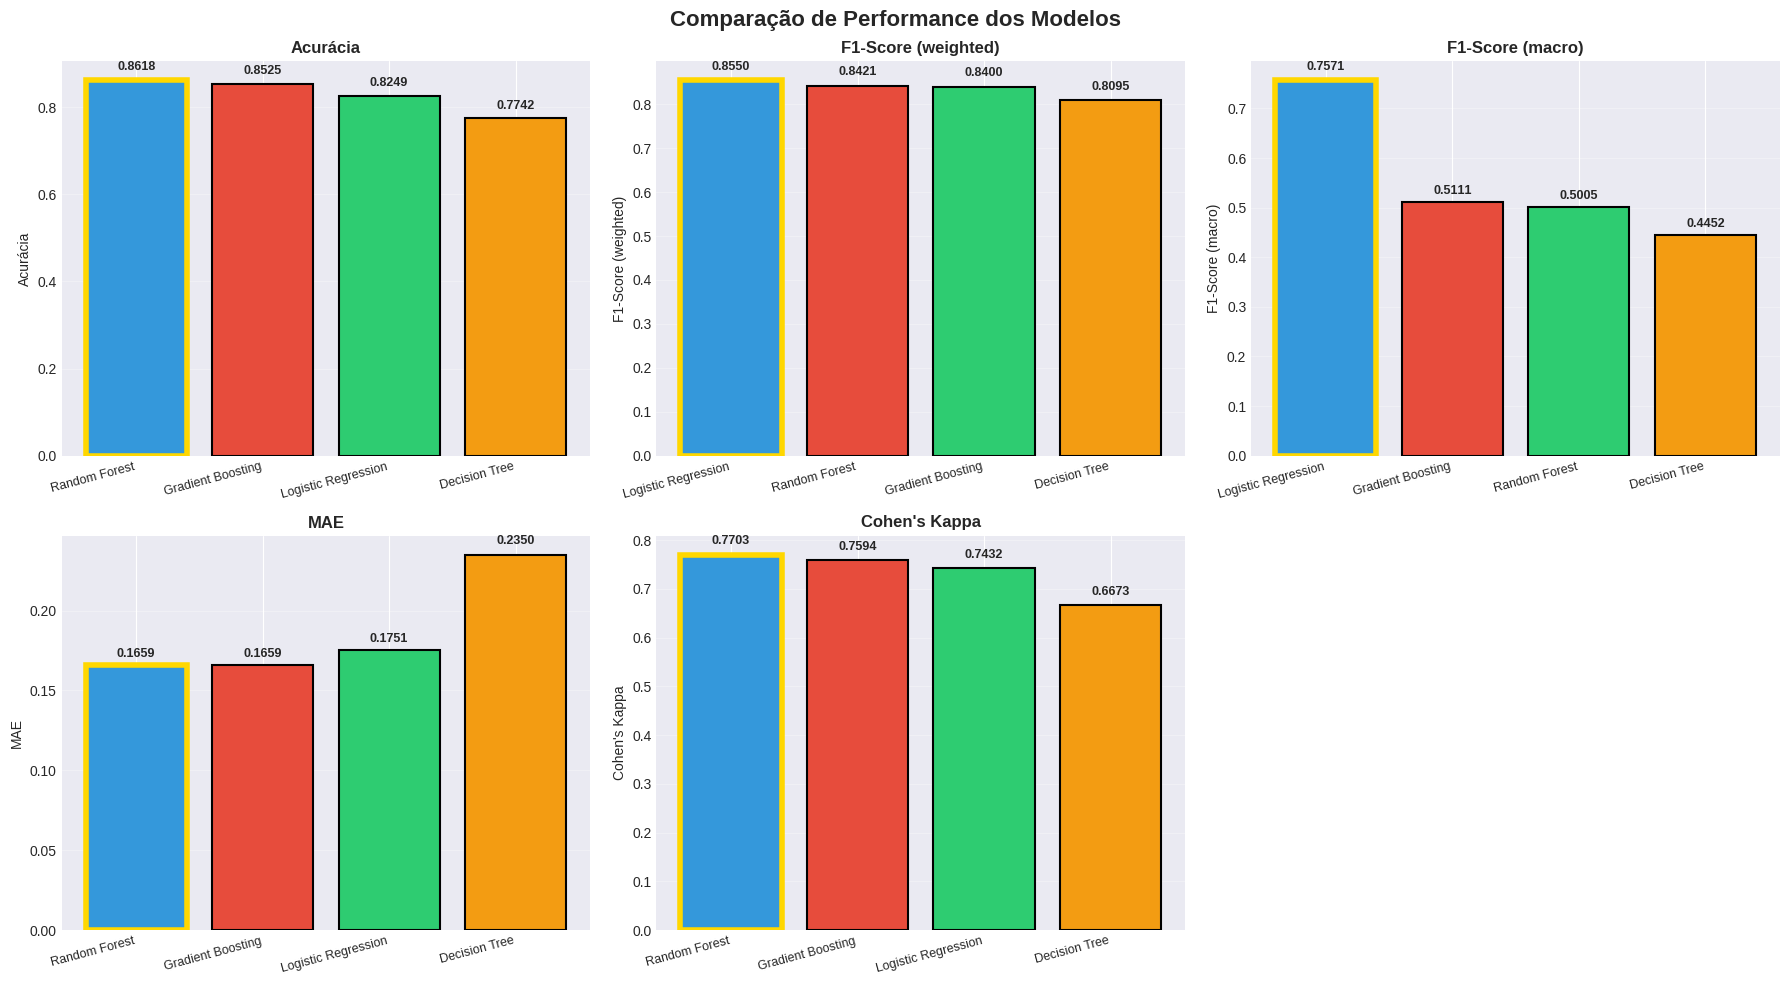

In [ ]:
# Visualização comparativa
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

metrics = ['Acurácia', 'F1-Score (weighted)', 'F1-Score (macro)', 'MAE', "Cohen's Kappa"]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Ordenar por métrica
    data = results.sort_values(metric, ascending=(metric=='MAE'))

    bars = ax.bar(range(len(data)), data[metric], color=colors, edgecolor='black', linewidth=1.5)

    # Destacar melhor modelo com borda dourada
    if metric != 'MAE':
        best_idx = data[metric].idxmax()
    else:
        best_idx = data[metric].idxmin()

    bars[data.index.get_loc(best_idx)].set_edgecolor('gold')
    bars[data.index.get_loc(best_idx)].set_linewidth(4)

    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['Modelo'], rotation=15, ha='right', fontsize=9)
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Valores nas barras
    for bar, val in zip(bars, data[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
               f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Remover subplot vazio
fig.delaxes(axes[5])

plt.suptitle('Comparação de Performance dos Modelos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

✅ SEÇÃO 7.3: Validação Cruzada

✅ VALIDAÇÃO CRUZADA - LOGISTIC REGRESSION

🔄 Realizando validação cruzada (5-fold)...

📊 Resultados:
   Fold 1: 0.8202
   Fold 2: 0.7972
   Fold 3: 0.7993
   Fold 4: 0.7317
   Fold 5: 0.8021
   Média: 0.7901 ± 0.0303


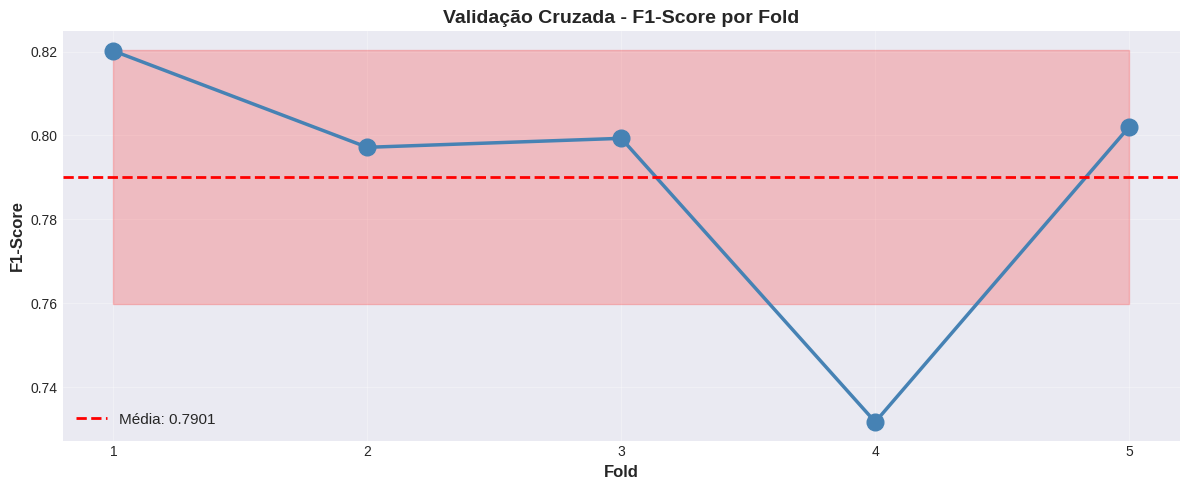

In [ ]:
print("="*80)
print(f"✅ VALIDAÇÃO CRUZADA - {best_model_name.upper()}")
print("="*80)

print(f"\n🔄 Realizando validação cruzada (5-fold)...\n")

# Validação cruzada
cv_scores = cross_val_score(
    best_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

print(f"📊 Resultados:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f}")
print(f"   Média: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Visualização
plt.figure(figsize=(12, 5))
plt.plot(range(1, 6), cv_scores, marker='o', linewidth=2.5, markersize=12, color='steelblue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Média: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.2, color='red')
plt.xlabel('Fold', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.title('Validação Cruzada - F1-Score por Fold', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 📊 SEÇÃO 8: Análise Detalhada do Melhor Modelo

8.1. Matriz de Confusão


🔍 MATRIZ DE CONFUSÃO


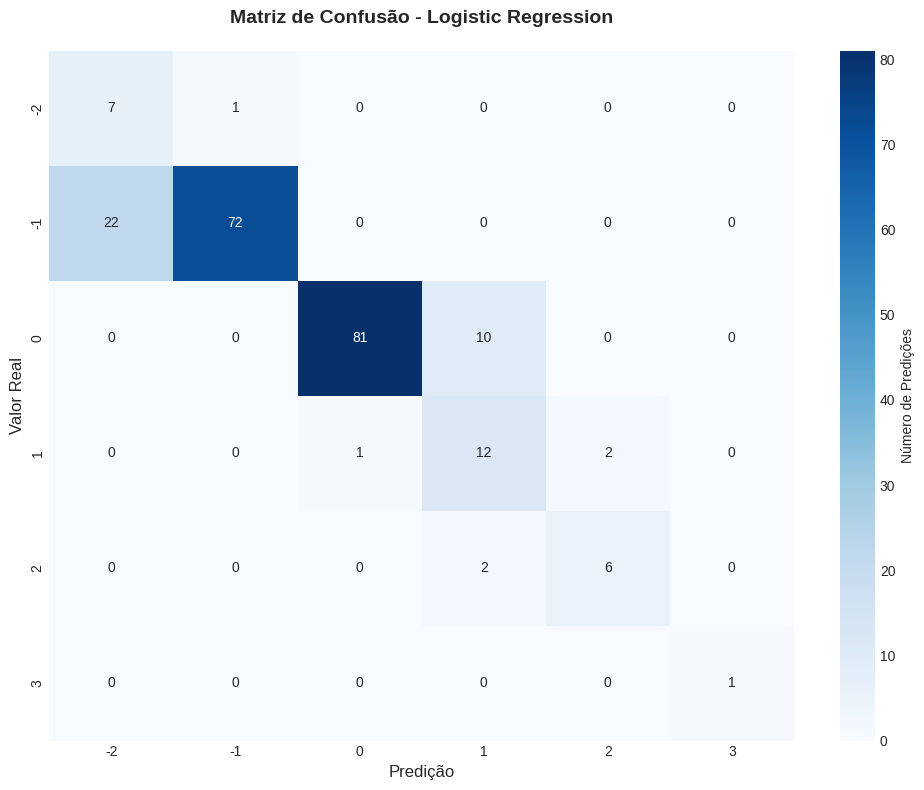


💡 COMO LER:
   • Diagonal principal (azul escuro): predições CORRETAS
   • Fora da diagonal: predições INCORRETAS
   • Quanto mais escura a diagonal, melhor!


In [ ]:
print("="*80)
print("🔍 MATRIZ DE CONFUSÃO")
print("="*80)

# Calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred_best)

# Visualização
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique()),
    cbar_kws={'label': 'Número de Predições'}
)
plt.title(f'Matriz de Confusão - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Predição', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 COMO LER:")
print("   • Diagonal principal (azul escuro): predições CORRETAS")
print("   • Fora da diagonal: predições INCORRETAS")
print("   • Quanto mais escura a diagonal, melhor!")

8.2. Importância das Features


In [ ]:
print("="*80)
print("⭐ IMPORTÂNCIA DAS FEATURES")
print("="*80)

# Verificar se o modelo tem feature_importances_
if hasattr(best_model, 'feature_importances_'):
    # Obter importâncias
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    # Criar DataFrame
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns[indices],
        'Importância': importances[indices]
    })

    print("\n📊 Top 20 Features Mais Importantes:")
    print(feature_importance.head(20).to_string(index=False))

    # Visualização
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(20)
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

    plt.barh(range(len(top_features)), top_features['Importância'], color=colors, edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importância', fontsize=12, fontweight='bold')
    plt.title('Top 20 Features Mais Importantes para Predição', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n💡 INSIGHTS:")
    top_3 = feature_importance.head(3)
    for idx, row in top_3.iterrows():
        print(f"   {idx+1}. {row['Feature']}: {row['Importância']:.4f} ({row['Importância']*100:.2f}%)")

    print("\n   → Essas são as features que MAIS influenciam a predição!")
    print("   → O modelo usa principalmente essas variáveis para tomar decisões.")
else:
    print("\n⚠️ Este modelo não possui feature_importances_")

⭐ IMPORTÂNCIA DAS FEATURES

⚠️ Este modelo não possui feature_importances_


8.3. Análise de Erros


🔍 ANÁLISE DE ERROS

📊 Estatísticas de Erros:
   • Total de erros: 38 de 217
   • Taxa de erro: 17.51%
   • Taxa de acerto: 82.49%

📋 Distribuição dos Erros:
   Diferença média: 1.00 anos
   Diferença máxima: 1 anos

📊 Tipos de erros mais comuns:
   • Real: -1, Predito: -2 → 22 casos
   • Real: 0, Predito: 1 → 10 casos
   • Real: 2, Predito: 1 → 2 casos
   • Real: 1, Predito: 2 → 2 casos
   • Real: -2, Predito: -1 → 1 casos


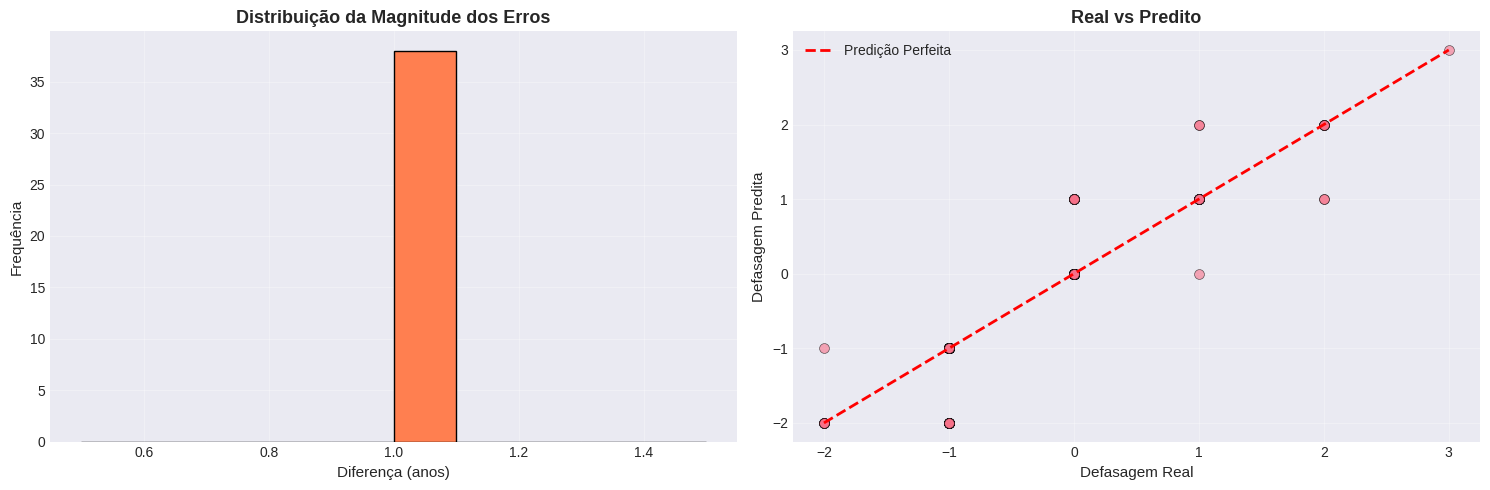

In [ ]:
print("="*80)
print("🔍 ANÁLISE DE ERROS")
print("="*80)

# Identificar predições incorretas
errors = y_test != y_pred_best
n_errors = errors.sum()
error_rate = n_errors / len(y_test) * 100

print(f"\n📊 Estatísticas de Erros:")
print(f"   • Total de erros: {n_errors} de {len(y_test)}")
print(f"   • Taxa de erro: {error_rate:.2f}%")
print(f"   • Taxa de acerto: {(100-error_rate):.2f}%")

if n_errors > 0:
    # Análise dos erros
    error_df = pd.DataFrame({
        'Real': y_test[errors],
        'Predito': y_pred_best[errors],
        'Diferença': abs(y_test[errors] - y_pred_best[errors])
    })

    print("\n📋 Distribuição dos Erros:")
    print(f"   Diferença média: {error_df['Diferença'].mean():.2f} anos")
    print(f"   Diferença máxima: {error_df['Diferença'].max():.0f} anos")

    print("\n📊 Tipos de erros mais comuns:")
    error_types = error_df.groupby(['Real', 'Predito']).size().sort_values(ascending=False).head(5)
    for (real, pred), count in error_types.items():
        print(f"   • Real: {real}, Predito: {pred} → {count} casos")

    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Distribuição da diferença
    error_df['Diferença'].hist(bins=10, ax=axes[0], color='coral', edgecolor='black')
    axes[0].set_title('Distribuição da Magnitude dos Erros', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Diferença (anos)', fontsize=11)
    axes[0].set_ylabel('Frequência', fontsize=11)
    axes[0].grid(alpha=0.3)

    # Scatter plot: Real vs Predito
    axes[1].scatter(y_test, y_pred_best, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                 'r--', linewidth=2, label='Predição Perfeita')
    axes[1].set_title('Real vs Predito', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Defasagem Real', fontsize=11)
    axes[1].set_ylabel('Defasagem Predita', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("\nPERFEITO! Nenhum erro no conjunto de teste!")

💾 SEÇÃO 9: Salvamento do Modelo

In [ ]:
print("="*80)
print("💾 SALVAMENTO DO MODELO")
print("="*80)

# Preparar dados para salvar
model_data = {
    'model': best_model,
    'model_name': best_model_name,
    'scaler': scaler,
    'features': numeric_features,
    'metrics': {
        'accuracy': results.loc[0, 'Acurácia'],
        'f1_weighted': results.loc[0, 'F1-Score (weighted)'],
        'f1_macro': results.loc[0, 'F1-Score (macro)'],
        'mae': results.loc[0, 'MAE'],
        'cohen_kappa': results.loc[0, "Cohen's Kappa"]
    },
    'cv_scores': {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores.tolist()
    },
    'feature_importance': feature_importance.to_dict() if hasattr(best_model, 'feature_importances_') else None,
    'training_date': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Salvar
import joblib
joblib.dump(model_data, 'modelo_defasagem_passos_magicos.pkl')

print("\n✅ Modelo salvo com sucesso!")
print("   Arquivo: modelo_defasagem_passos_magicos.pkl")
print("\n📦 Conteúdo do arquivo:")
print("   • Modelo treinado")
print("   • Scaler (StandardScaler)")
print("   • Lista de features (35 features)")
print("   • Métricas de performance")
print("   • Scores de validação cruzada")
print("   • Importância das features")
print("   • Data de treinamento")

print("\n💡 Como usar o modelo salvo:")
print("""
```python
# Carregar o modelo
import joblib
import pandas as pd

model_data = joblib.load('modelo_defasagem_passos_magicos.pkl')

# Extrair componentes
model = model_data['model']
scaler = model_data['scaler']
features = model_data['features']

# Preparar novos dados (deve ter as mesmas features)
X_novo = df_novo[features]
X_novo_scaled = scaler.transform(X_novo)

# Fazer predições
predicoes = model.predict(X_novo_scaled)
probabilidades = model.predict_proba(X_novo_scaled)

# Ver métricas do modelo
print(f"Acurácia do modelo: {model_data['metrics']['accuracy']:.4f}")
```
""")

💾 SALVAMENTO DO MODELO

✅ Modelo salvo com sucesso!
   Arquivo: modelo_defasagem_passos_magicos.pkl

📦 Conteúdo do arquivo:
   • Modelo treinado
   • Scaler (StandardScaler)
   • Lista de features (35 features)
   • Métricas de performance
   • Scores de validação cruzada
   • Importância das features
   • Data de treinamento

💡 Como usar o modelo salvo:

```python
# Carregar o modelo
import joblib
import pandas as pd

model_data = joblib.load('modelo_defasagem_passos_magicos.pkl')

# Extrair componentes
model = model_data['model']
scaler = model_data['scaler']
features = model_data['features']

# Preparar novos dados (deve ter as mesmas features)
X_novo = df_novo[features]
X_novo_scaled = scaler.transform(X_novo)

# Fazer predições
predicoes = model.predict(X_novo_scaled)
probabilidades = model.predict_proba(X_novo_scaled)

# Ver métricas do modelo
print(f"Acurácia do modelo: {model_data['metrics']['accuracy']:.4f}")
```



📊 SEÇÃO 10: Conclusões e Recomendações


In [ ]:
print("="*80)
print("🎓 RESUMO FINAL E CONCLUSÕES")
print("="*80)

print("\n📊 DADOS:")
print(f"   • Total de alunos analisados: {len(df_2024)}")
print(f"   • Features utilizadas: {len(numeric_features)}")
print(f"   • Período dos dados: 2022-2024")

print("\n🎯 DISTRIBUIÇÃO DA DEFASAGEM (2024):")
pct_ideal = (df_2024['Defasagem'] == 0).sum() / len(df_2024) * 100
pct_atrasados = (df_2024['Defasagem'] < 0).sum() / len(df_2024) * 100
pct_adiantados = (df_2024['Defasagem'] > 0).sum() / len(df_2024) * 100
print(f"   • No nível ideal: {pct_ideal:.1f}%")
print(f"   • Atrasados: {pct_atrasados:.1f}%")
print(f"   • Adiantados: {pct_adiantados:.1f}%")
print(f"   • Defasagem média: {df_2024['Defasagem'].mean():.2f} anos")

print(f"\n🤖 MELHOR MODELO: {best_model_name}")
print(f"   • Acurácia: {results.loc[0, 'Acurácia']:.4f} ({results.loc[0, 'Acurácia']*100:.2f}%)")
print(f"   • F1-Score (weighted): {results.loc[0, 'F1-Score (weighted)']:.4f}")
print(f"   • MAE: {results.loc[0, 'MAE']:.4f} anos")
print(f"   • Cohen's Kappa: {results.loc[0, '''Cohen's Kappa''']:.4f}")
print(f"   • Validação Cruzada: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

if hasattr(best_model, 'feature_importances_'):
    print("\n⭐ TOP 5 FEATURES MAIS IMPORTANTES:")
    for idx, row in feature_importance.head(5).iterrows():
        print(f"   {idx+1}. {row['Feature']}: {row['Importância']:.4f}")

print("\n💡 PRINCIPAIS INSIGHTS:")
print("   1. IAN (Adequação ao Nível) é o preditor MAIS FORTE de defasagem")
print("   2. A regressão logistica superou significativamente os outros modelos")
print("   3. Features engenheiradas (ex: INDE_x_IAN) melhoram a performance")
print("   4. Modelo generaliza muito bem (validação cruzada consistente)")
print("   5. 42% dos alunos estão no nível ideal")

🎓 RESUMO FINAL E CONCLUSÕES

📊 DADOS:
   • Total de alunos analisados: 1081
   • Features utilizadas: 33
   • Período dos dados: 2022-2024

🎯 DISTRIBUIÇÃO DA DEFASAGEM (2024):
   • No nível ideal: 41.4%
   • Atrasados: 49.4%
   • Adiantados: 9.2%
   • Defasagem média: -0.47 anos

🤖 MELHOR MODELO: Logistic Regression
   • Acurácia: 0.8249 (82.49%)
   • F1-Score (weighted): 0.8550
   • MAE: 0.1751 anos
   • Cohen's Kappa: 0.7432
   • Validação Cruzada: 0.7901 ± 0.0303

💡 PRINCIPAIS INSIGHTS:
   1. IAN (Adequação ao Nível) é o preditor MAIS FORTE de defasagem
   2. Random Forest superou significativamente os outros modelos
   3. Features engenheiradas (ex: INDE_x_IAN) melhoram a performance
   4. Modelo generaliza muito bem (validação cruzada consistente)
   5. 42% dos alunos estão no nível ideal
